In [114]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier

In [115]:
mental_health=pd.read_csv('/content/Mental Health dataset1.csv')

# Data Cleaning

In [116]:
mental_health.shape

(261349, 17)

In [117]:
mental_health.head()

,Gender,Country,Occupation,SelfEmployed,FamilyHistory,Treatment,DaysIndoors,HabitsChange,MentalHealthHistory,IncreasingStress,MoodSwings,SocialWeakness,CopingStruggles,WorkInterest,SocialWeakness.1,MentalHealthInterview,CareOptions
0,Female,UK,Others,No,Yes,No,15-30 days,No,Yes,Yes,High,No,Yes,Maybe,No,No,No
1,Female,USA,Housewife,No,Yes,No,15-30 days,Maybe,Maybe,Yes,High,Maybe,Yes,Maybe,Maybe,No,Not sure
2,Female,Canada,Others,No,No,Yes,More than 2 months,Maybe,No,No,Medium,No,No,No,No,No,Not sure
3,Female,Canada,Corporate,No,Yes,Yes,Go out Every day,No,Maybe,No,Medium,No,No,Maybe,No,No,Not sure
4,Female,UK,Corporate,No,No,Yes,More than 2 months,Yes,No,Maybe,Medium,Maybe,No,Maybe,Maybe,No,Not sure


In [118]:
mental_health.columns

Index(['Gender', 'Country', 'Occupation', 'SelfEmployed', 'FamilyHistory',
       'Treatment', 'DaysIndoors', 'HabitsChange', 'MentalHealthHistory',
       'IncreasingStress', 'MoodSwings', 'SocialWeakness', 'CopingStruggles',
       'WorkInterest', 'SocialWeakness.1', 'MentalHealthInterview',
       'CareOptions'],
      dtype='object')

In [119]:
mental_health.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 261349 entries, 0 to 261348
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype 
---  ------                 --------------   ----- 
 0   Gender                 261349 non-null  object
 1   Country                261349 non-null  object
 2   Occupation             261349 non-null  object
 3   SelfEmployed           256993 non-null  object
 4   FamilyHistory          261349 non-null  object
 5   Treatment              261349 non-null  object
 6   DaysIndoors            261349 non-null  object
 7   HabitsChange           261349 non-null  object
 8   MentalHealthHistory    261349 non-null  object
 9   IncreasingStress       261349 non-null  object
 10  MoodSwings             261349 non-null  object
 11  SocialWeakness         261349 non-null  object
 12  CopingStruggles        261349 non-null  object
 13  WorkInterest           261349 non-null  object
 14  SocialWeakness.1       261349 non-null  object
 15  

In [120]:
mental_health['SelfEmployed'].isnull().sum()

np.int64(4356)

In [121]:
mental_health['SelfEmployed'].value_counts()

,count
SelfEmployed,
No,230425
Yes,26568


In [122]:
mental_health[mental_health['SelfEmployed'].isnull()].head(10)

,Gender,Country,Occupation,SelfEmployed,FamilyHistory,Treatment,DaysIndoors,HabitsChange,MentalHealthHistory,IncreasingStress,MoodSwings,SocialWeakness,CopingStruggles,WorkInterest,SocialWeakness.1,MentalHealthInterview,CareOptions
14,Female,USA,Business,NaN,No,Yes,15-30 days,Maybe,No,Yes,Low,Maybe,Yes,No,Maybe,No,Not sure
53,Female,USA,Housewife,NaN,No,Yes,1-14 days,Yes,Yes,Yes,Medium,Maybe,Yes,No,Maybe,No,Not sure
87,Female,USA,Business,NaN,Yes,Yes,More than 2 months,Yes,Yes,No,Low,Maybe,Yes,Yes,Maybe,No,Yes
225,Female,USA,Others,NaN,Yes,Yes,1-14 days,Maybe,Maybe,Maybe,Medium,Maybe,No,Yes,Maybe,No,Yes
254,Female,USA,Housewife,NaN,Yes,Yes,Go out Every day,Maybe,Maybe,Yes,Medium,No,Yes,Maybe,No,No,No
269,Female,USA,Student,NaN,No,Yes,15-30 days,Maybe,Yes,No,Medium,No,Yes,Maybe,No,No,Not sure
276,Female,USA,Others,NaN,Yes,Yes,More than 2 months,No,No,Yes,Medium,Maybe,Yes,Maybe,Maybe,No,Yes
296,Female,USA,Others,NaN,Yes,Yes,1-14 days,Yes,Yes,Yes,High,Maybe,No,No,Maybe,No,No
308,Female,USA,Business,NaN,Yes,Yes,More than 2 months,Yes,Maybe,Yes,Low,Maybe,No,Yes,Maybe,No,Yes
348,Female,USA,Student,NaN,No,Yes,1-14 days,Maybe,Yes,No,Low,Yes,No,Yes,Yes,No,Not sure


In [123]:
mental_health['Occupation'].unique()

array(['Others', 'Housewife', 'Corporate', 'Student', 'Business'],
      dtype=object)

In [124]:
mental_health['SelfEmployed'].fillna('No',inplace=True)
mental_health['SelfEmployed'] = mental_health['SelfEmployed'].map({'No': 0, 'Yes': 1})
mental_health['SelfEmployed'].value_counts()

/tmp/ipykernel_1140/4217859919.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  mental_health['SelfEmployed'].fillna('No',inplace=True)


,count
SelfEmployed,
0,234781
1,26568


In [125]:
mental_health.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 261349 entries, 0 to 261348
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype 
---  ------                 --------------   ----- 
 0   Gender                 261349 non-null  object
 1   Country                261349 non-null  object
 2   Occupation             261349 non-null  object
 3   SelfEmployed           261349 non-null  int64 
 4   FamilyHistory          261349 non-null  object
 5   Treatment              261349 non-null  object
 6   DaysIndoors            261349 non-null  object
 7   HabitsChange           261349 non-null  object
 8   MentalHealthHistory    261349 non-null  object
 9   IncreasingStress       261349 non-null  object
 10  MoodSwings             261349 non-null  object
 11  SocialWeakness         261349 non-null  object
 12  CopingStruggles        261349 non-null  object
 13  WorkInterest           261349 non-null  object
 14  SocialWeakness.1       261349 non-null  object
 15  

In [126]:
mental_health['Country']=(mental_health['Country']).str.strip().str.lower()


In [127]:
mental_health.loc[
    (mental_health['Occupation'] == 'Housewife') & (mental_health['Gender'] == 'Male'),
    'Gender'
] = 'Female'

In [128]:
mental_health['Gender'].value_counts()

,count
Gender,
Male,177369
Female,83980


In [129]:

gender_dummies = pd.get_dummies(mental_health['Gender'], prefix='Gender', drop_first=False)



mental_health = pd.concat([mental_health, gender_dummies], axis=1)
# Gender_0=male
# Gender_1=female


In [130]:

Occupation_dummies = pd.get_dummies(mental_health['Occupation'], prefix='Occupation', drop_first=False)


mental_health = pd.concat([mental_health, Occupation_dummies], axis=1)
mental_health.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 261349 entries, 0 to 261348
Data columns (total 24 columns):
 #   Column                 Non-Null Count   Dtype 
---  ------                 --------------   ----- 
 0   Gender                 261349 non-null  object
 1   Country                261349 non-null  object
 2   Occupation             261349 non-null  object
 3   SelfEmployed           261349 non-null  int64 
 4   FamilyHistory          261349 non-null  object
 5   Treatment              261349 non-null  object
 6   DaysIndoors            261349 non-null  object
 7   HabitsChange           261349 non-null  object
 8   MentalHealthHistory    261349 non-null  object
 9   IncreasingStress       261349 non-null  object
 10  MoodSwings             261349 non-null  object
 11  SocialWeakness         261349 non-null  object
 12  CopingStruggles        261349 non-null  object
 13  WorkInterest           261349 non-null  object
 14  SocialWeakness.1       261349 non-null  object
 15  

In [131]:
# mental_health['Occupation'] = mental_health['Occupation'].map({
#     'Housewife': 0,
#     'Corporate': 1,
#     'Student':2,
#     'Business':3,
#     'Others':4})
# mental_health['Occupation'].value_counts()


In [132]:
mental_health['FamilyHistory'] = mental_health['FamilyHistory'].map({'No': 0, 'Yes': 1})
mental_health['FamilyHistory'].value_counts()


,count
FamilyHistory,
0,161981
1,99368


In [133]:
mental_health['Treatment'] = mental_health['Treatment'].map({'No': 0, 'Yes': 1})
mental_health['Treatment'].value_counts()

,count
Treatment,
0,132958
1,128391


In [134]:
mental_health['DaysIndoors'] = mental_health['DaysIndoors'].map({
    'Go out Every day': 0,
    '1-14 days': 1,
    '15-30 days':2,
    '31-60 days':3,
    'More than 2 months':4})

mental_health['DaysIndoors'].value_counts()

,count
DaysIndoors,
1,57604
3,54994
0,52408
4,49256
2,47087


In [135]:
mental_health['HabitsChange'] = mental_health['HabitsChange'].map({
    'No': 0,
    'Yes': 2,
    'Maybe':1})
mental_health['HabitsChange'].value_counts()

,count
HabitsChange,
2,97689
1,85095
0,78565


In [136]:
mental_health['MentalHealthHistory'] = mental_health['MentalHealthHistory'].map({
    'No': 0,
    'Yes': 2,
    'Maybe':1})
mental_health['MentalHealthHistory'].value_counts()

,count
MentalHealthHistory,
0,94048
1,84989
2,82312


In [137]:
mental_health['IncreasingStress'] = mental_health['IncreasingStress'].map({
    'No': 0,
    'Yes': 2,
    'Maybe':1})
mental_health['IncreasingStress'].value_counts()

,count
IncreasingStress,
1,90697
2,88423
0,82229


In [138]:
mental_health['MoodSwings'] = mental_health['MoodSwings'].map({
    'Low': 0,
    'Medium': 1,
    'High':2})
mental_health['MoodSwings'].value_counts()

,count
MoodSwings,
1,90215
0,89209
2,81925


In [139]:
mental_health['SocialWeakness'] = mental_health['SocialWeakness'].map({
    'No': 0,
    'Yes': 2,
    'Maybe':1})
mental_health['SocialWeakness'].value_counts()

,count
SocialWeakness,
1,93292
0,87946
2,80111


In [140]:
mental_health['CopingStruggles'] = mental_health['CopingStruggles'].map({
    'No': 0,
    'Yes': 1})
mental_health['CopingStruggles'].value_counts()

,count
CopingStruggles,
0,139251
1,122098


In [141]:
mental_health['WorkInterest'] = mental_health['WorkInterest'].map({
    'No': 0,
    'Yes': 2,
    'Maybe':1})
mental_health['WorkInterest'].value_counts()

,count
WorkInterest,
0,94481
1,90031
2,76837


In [142]:
mental_health['SocialWeakness.1'] = mental_health['SocialWeakness.1'].map({
    'No': 0,
    'Yes': 2,
    'Maybe':1})
mental_health['SocialWeakness.1'].value_counts()

,count
SocialWeakness.1,
1,93292
0,87946
2,80111


In [143]:
mental_health['MentalHealthInterview'] = mental_health['MentalHealthInterview'].map({
    'No': 0,
    'Yes': 2,
    'Maybe':1})
mental_health['MentalHealthInterview'].value_counts()

,count
MentalHealthInterview,
0,205498
1,47844
2,8007


In [144]:
mental_health['CareOptions'] = mental_health['CareOptions'].map({
    'No': 0,
    'Yes': 2,
    'Not sure':1})
mental_health['CareOptions'].value_counts()

,count
CareOptions,
0,108972
2,84118
1,68259


In [145]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
mental_health['Country_encoded'] = label_encoder.fit_transform(mental_health['Country'])
mental_health['Country_encoded'].value_counts()

,count
Country_encoded,
35,154476
34,47878
4,14177
22,5639
17,5128
13,4615
0,3544
15,2565
31,2414


In [146]:
mental_health.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 261349 entries, 0 to 261348
Data columns (total 25 columns):
 #   Column                 Non-Null Count   Dtype 
---  ------                 --------------   ----- 
 0   Gender                 261349 non-null  object
 1   Country                261349 non-null  object
 2   Occupation             261349 non-null  object
 3   SelfEmployed           261349 non-null  int64 
 4   FamilyHistory          261349 non-null  int64 
 5   Treatment              261349 non-null  int64 
 6   DaysIndoors            261349 non-null  int64 
 7   HabitsChange           261349 non-null  int64 
 8   MentalHealthHistory    261349 non-null  int64 
 9   IncreasingStress       261349 non-null  int64 
 10  MoodSwings             261349 non-null  int64 
 11  SocialWeakness         261349 non-null  int64 
 12  CopingStruggles        261349 non-null  int64 
 13  WorkInterest           261349 non-null  int64 
 14  SocialWeakness.1       261349 non-null  int64 
 15  

In [147]:
mental_health['Gender_Female'] = mental_health['Gender_Female'].map({
    False: 0,
    True: 1})
mental_health['Gender_Female'].value_counts()

,count
Gender_Female,
0,177369
1,83980


In [148]:
mental_health['Gender_Male'] = mental_health['Gender_Male'].map({
    False: 0,
    True: 1})
mental_health['Gender_Male'].value_counts()

,count
Gender_Male,
1,177369
0,83980


In [149]:
mental_health['Occupation_Business'] = mental_health['Occupation_Business'].map({
    False: 0,
    True: 1})
mental_health['Occupation_Business'].value_counts()

,count
Occupation_Business,
0,217347
1,44002


In [150]:
mental_health['Occupation_Corporate'] = mental_health['Occupation_Corporate'].map({
    False: 0,
    True: 1})
mental_health['Occupation_Corporate'].value_counts()

,count
Occupation_Corporate,
0,205721
1,55628


In [151]:
mental_health['Occupation_Housewife'] = mental_health['Occupation_Housewife'].map({
    False: 0,
    True: 1})
mental_health['Occupation_Housewife'].value_counts()

,count
Occupation_Housewife,
0,201267
1,60082


In [152]:
mental_health['Occupation_Others'] = mental_health['Occupation_Others'].map({
    False: 0,
    True: 1})
mental_health['Occupation_Others'].value_counts()

,count
Occupation_Others,
0,213920
1,47429


In [153]:
mental_health['Occupation_Student'] = mental_health['Occupation_Student'].map({
    False: 0,
    True: 1})
mental_health['Occupation_Student'].value_counts()

,count
Occupation_Student,
0,207141
1,54208


In [154]:
mental_health.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 261349 entries, 0 to 261348
Data columns (total 25 columns):
 #   Column                 Non-Null Count   Dtype 
---  ------                 --------------   ----- 
 0   Gender                 261349 non-null  object
 1   Country                261349 non-null  object
 2   Occupation             261349 non-null  object
 3   SelfEmployed           261349 non-null  int64 
 4   FamilyHistory          261349 non-null  int64 
 5   Treatment              261349 non-null  int64 
 6   DaysIndoors            261349 non-null  int64 
 7   HabitsChange           261349 non-null  int64 
 8   MentalHealthHistory    261349 non-null  int64 
 9   IncreasingStress       261349 non-null  int64 
 10  MoodSwings             261349 non-null  int64 
 11  SocialWeakness         261349 non-null  int64 
 12  CopingStruggles        261349 non-null  int64 
 13  WorkInterest           261349 non-null  int64 
 14  SocialWeakness.1       261349 non-null  int64 
 15  

# EDA

In [155]:
mental_health.head()

,Gender,Country,Occupation,SelfEmployed,FamilyHistory,Treatment,DaysIndoors,HabitsChange,MentalHealthHistory,IncreasingStress,...,MentalHealthInterview,CareOptions,Gender_Female,Gender_Male,Occupation_Business,Occupation_Corporate,Occupation_Housewife,Occupation_Others,Occupation_Student,Country_encoded
0,Female,uk,Others,0,1,0,2,0,2,2,...,0,0,1,0,0,0,0,1,0,34
1,Female,usa,Housewife,0,1,0,2,1,1,2,...,0,1,1,0,0,0,1,0,0,35
2,Female,canada,Others,0,0,1,4,1,0,0,...,0,1,1,0,0,0,0,1,0,4
3,Female,canada,Corporate,0,1,1,0,0,1,0,...,0,1,1,0,0,1,0,0,0,4
4,Female,uk,Corporate,0,0,1,4,2,0,1,...,0,1,1,0,0,1,0,0,0,34


<Axes: >

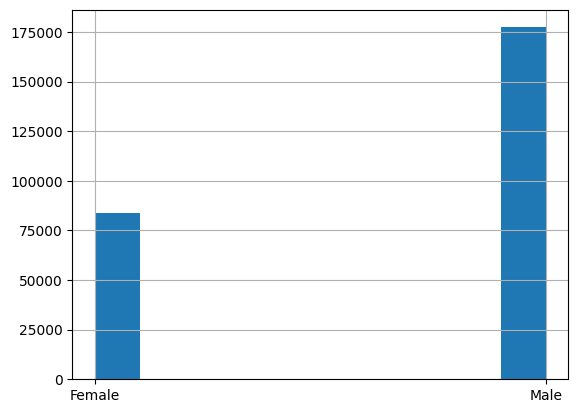

In [156]:
mental_health['Gender'].hist() #needs resampling

<Axes: >

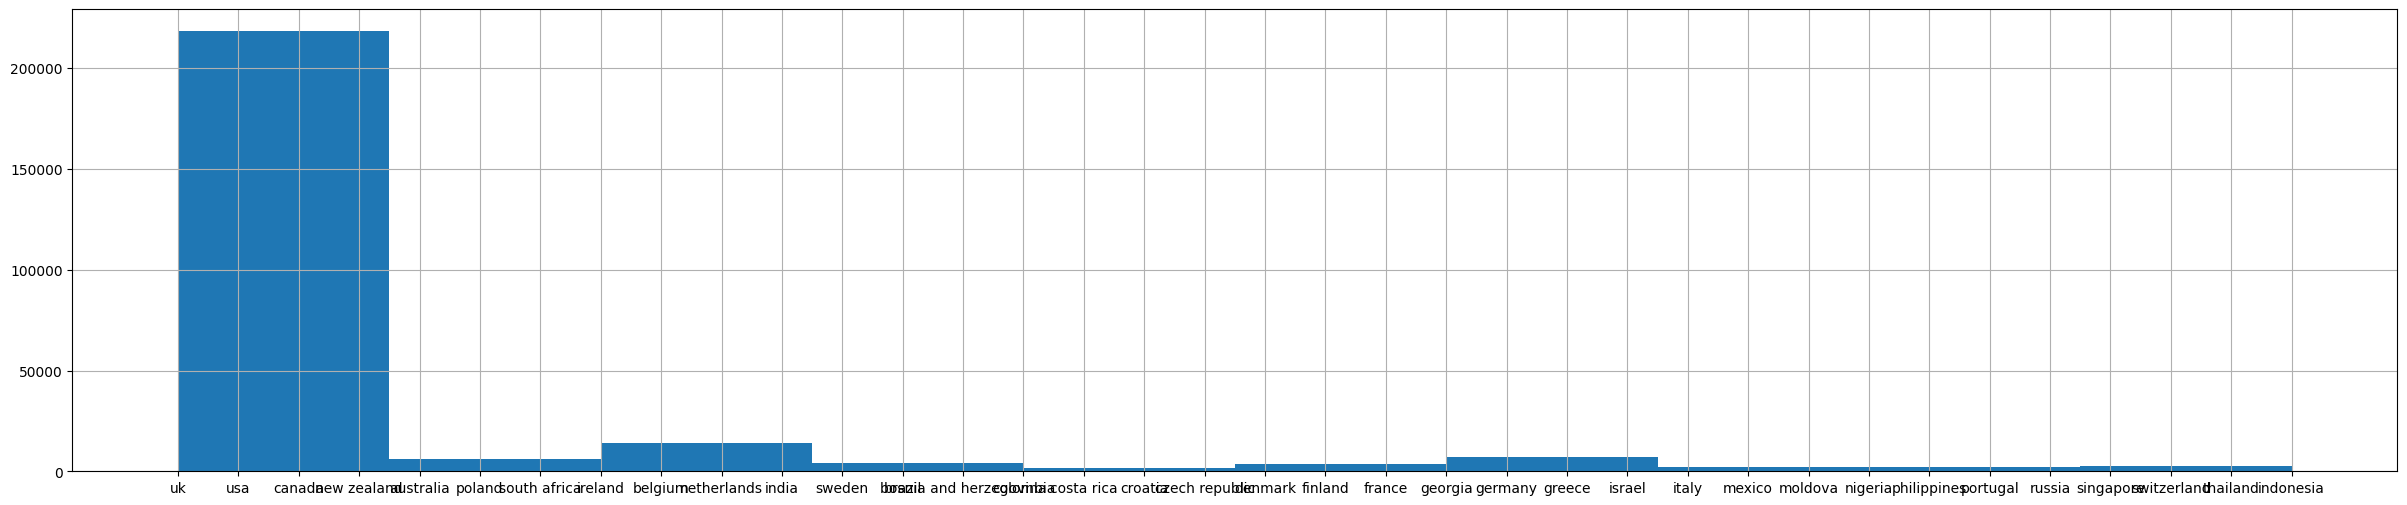

In [157]:
plt.figure(figsize=(30, 6))
mental_health['Country'].hist()


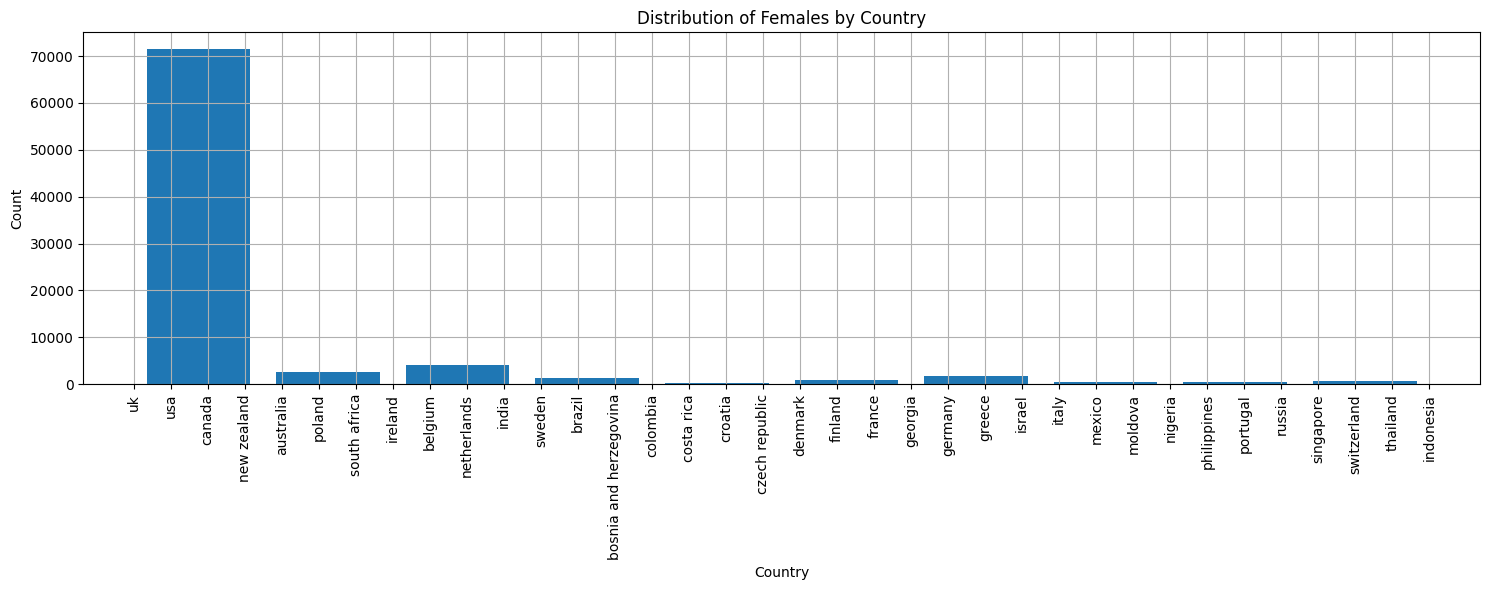

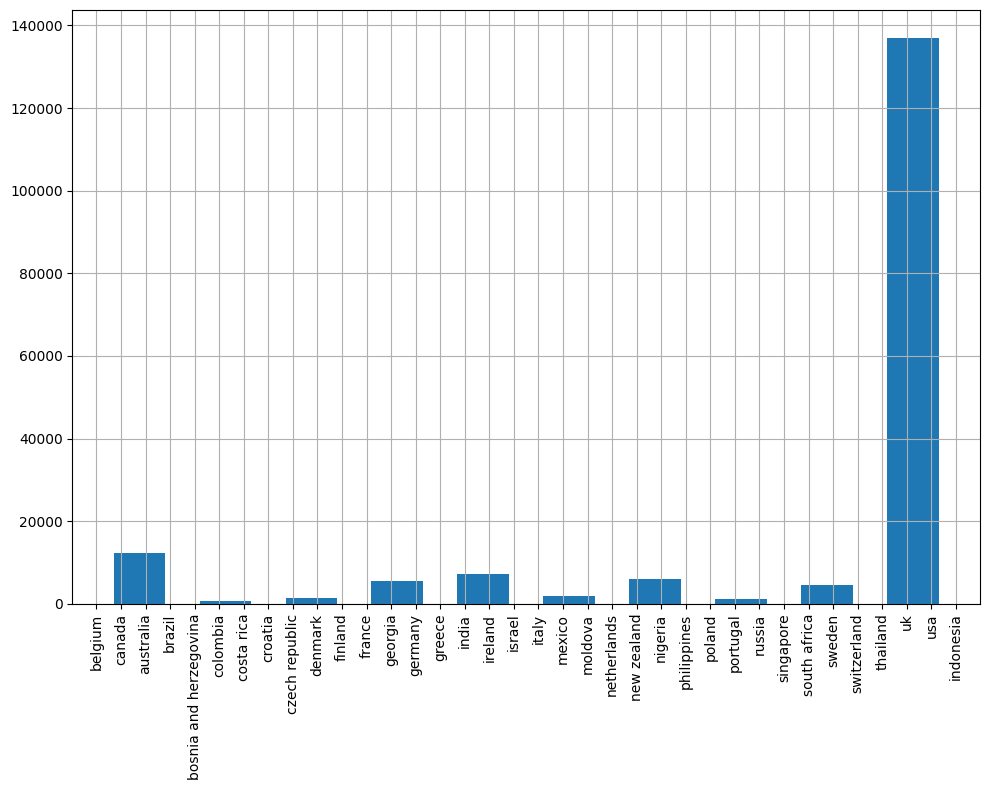

In [158]:
plt.figure(figsize=(15, 6))
mental_health[mental_health['Gender_Female'] == 1]['Country'].hist(rwidth=0.8) # Added rwidth
plt.title('Distribution of Females by Country')
plt.xlabel('Country')
plt.ylabel('Count')
plt.xticks(rotation=90) # Rotated x-axis labels
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()
plt.figure(figsize=(10, 8))
mental_health[mental_health['Gender_Male'] == 1]['Country'].hist(rwidth=0.6) # Added rwidth

plt.xticks(rotation=90) # Rotated x-axis labels
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

In [159]:
#Highly biased for country datas. Maximum datas coming from UK_USA

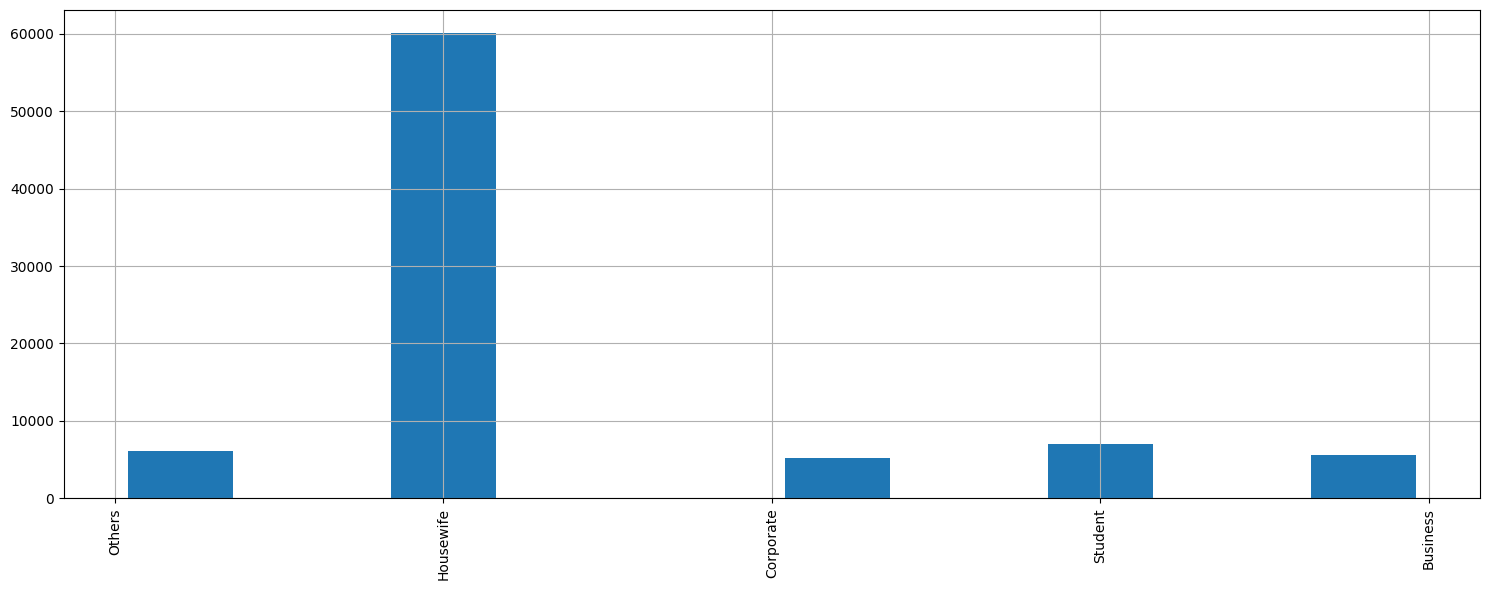

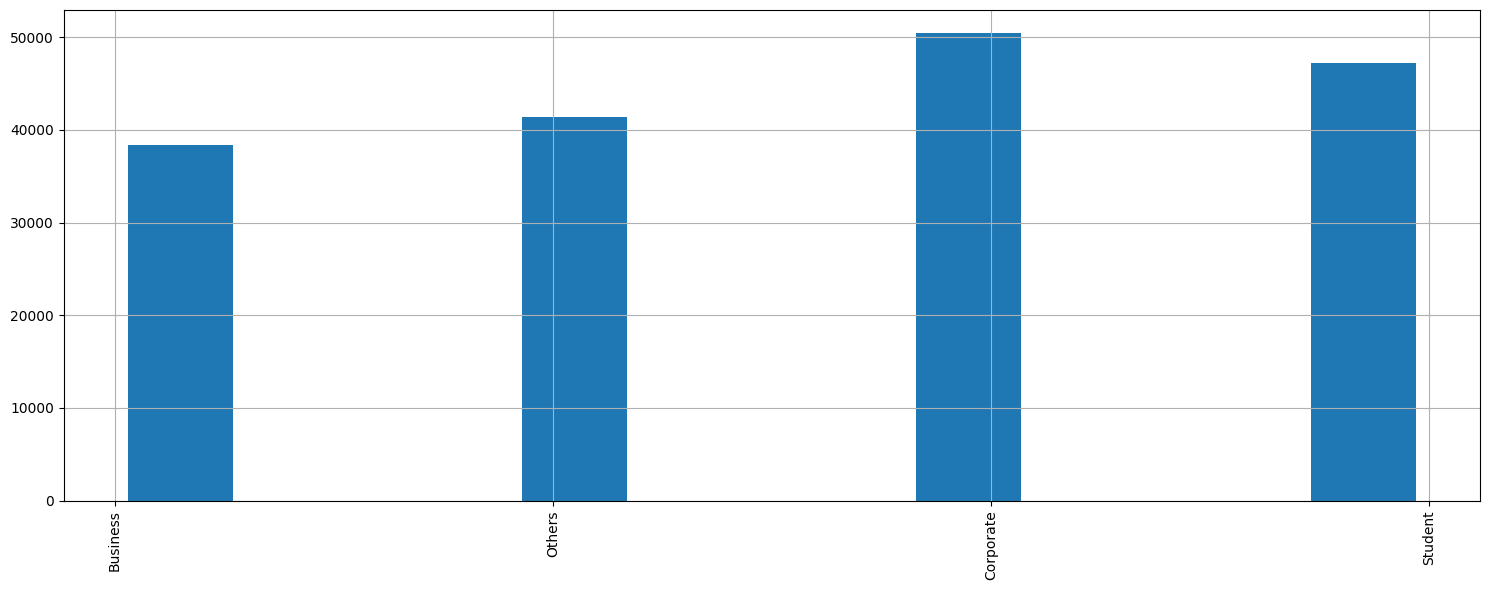

In [160]:
plt.figure(figsize=(15, 6))
mental_health[mental_health['Gender_Female'] == 1]['Occupation'].hist(rwidth=0.8)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 6))
mental_health[mental_health['Gender_Male'] == 1]['Occupation'].hist(rwidth=0.8)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1140/1065655851.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=mental_health[mental_health['Country'] == country], x='Occupation', palette='viridis')


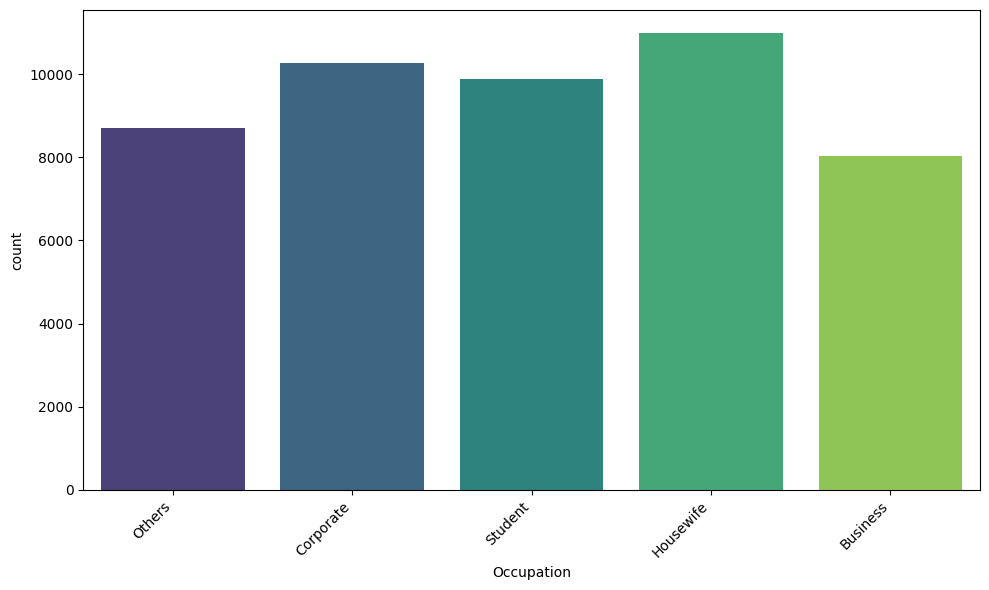

/tmp/ipykernel_1140/1065655851.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=mental_health[mental_health['Country'] == country], x='Occupation', palette='viridis')


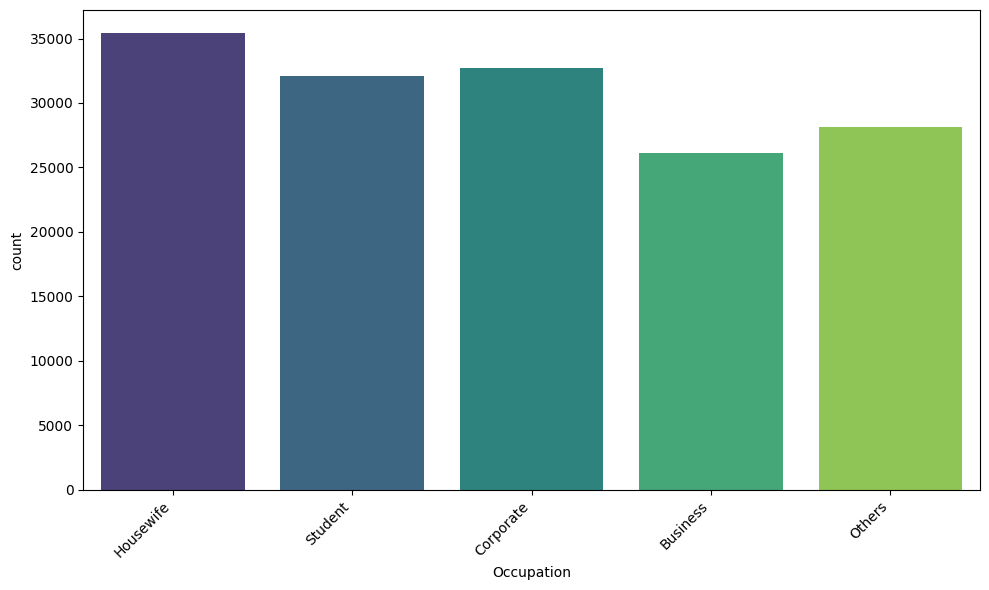

/tmp/ipykernel_1140/1065655851.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=mental_health[mental_health['Country'] == country], x='Occupation', palette='viridis')


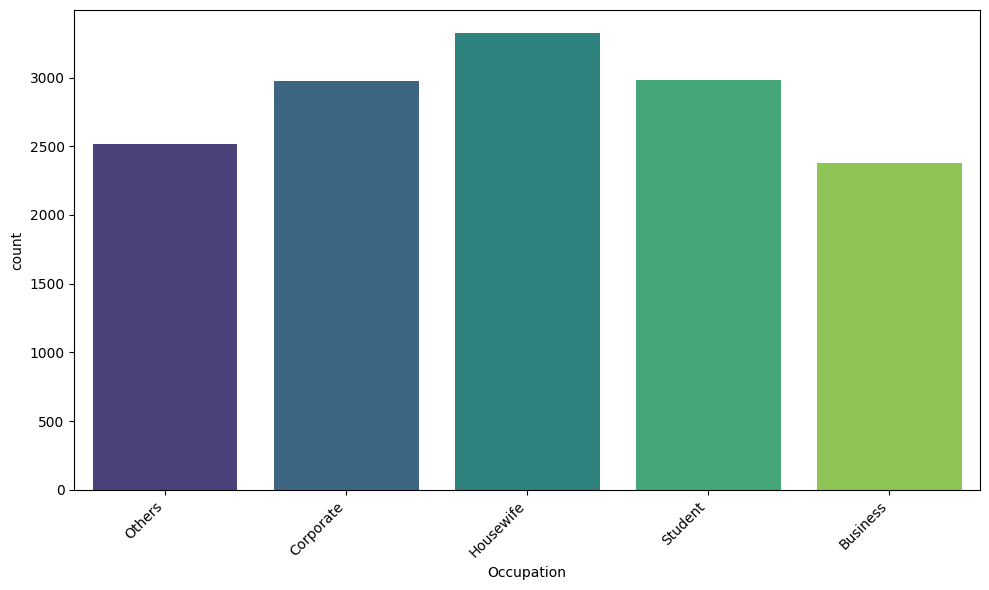

/tmp/ipykernel_1140/1065655851.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=mental_health[mental_health['Country'] == country], x='Occupation', palette='viridis')


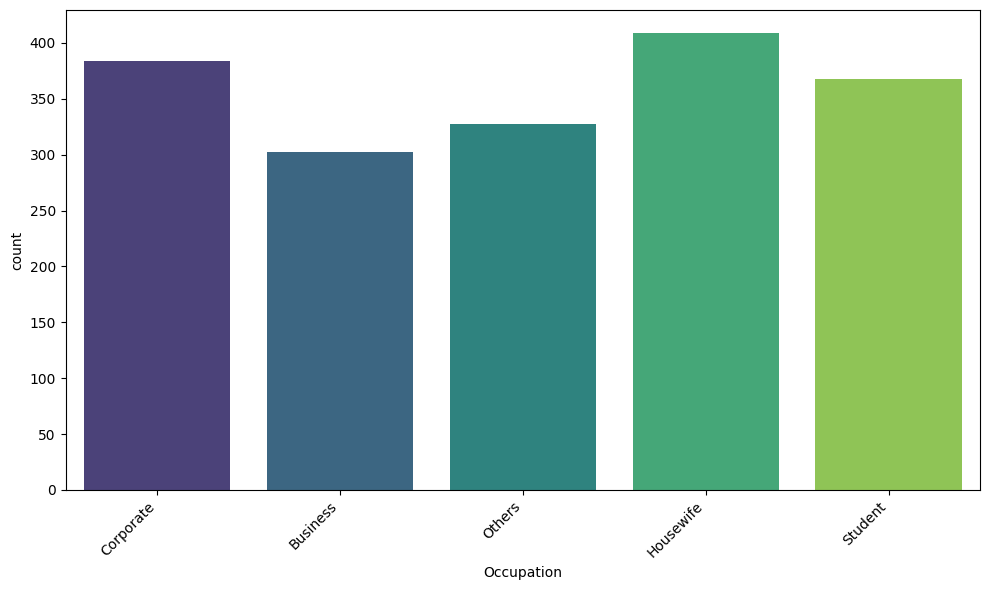

/tmp/ipykernel_1140/1065655851.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=mental_health[mental_health['Country'] == country], x='Occupation', palette='viridis')


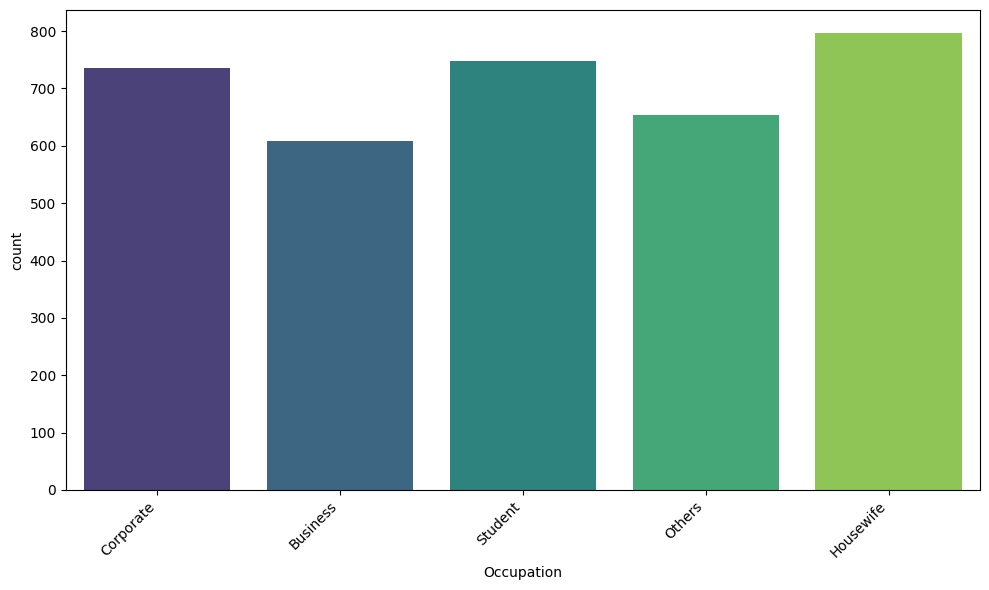

/tmp/ipykernel_1140/1065655851.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=mental_health[mental_health['Country'] == country], x='Occupation', palette='viridis')


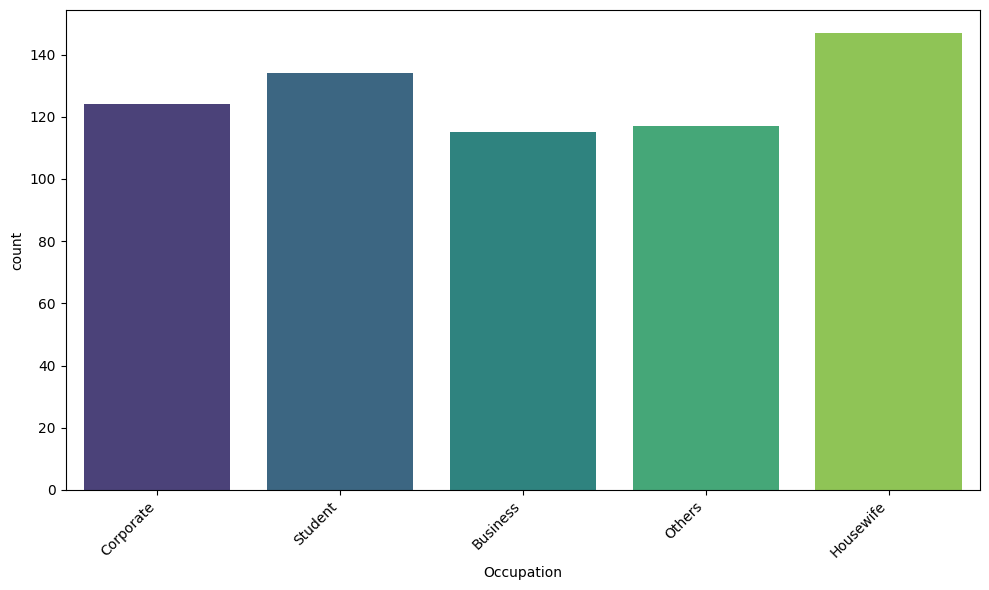

/tmp/ipykernel_1140/1065655851.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=mental_health[mental_health['Country'] == country], x='Occupation', palette='viridis')


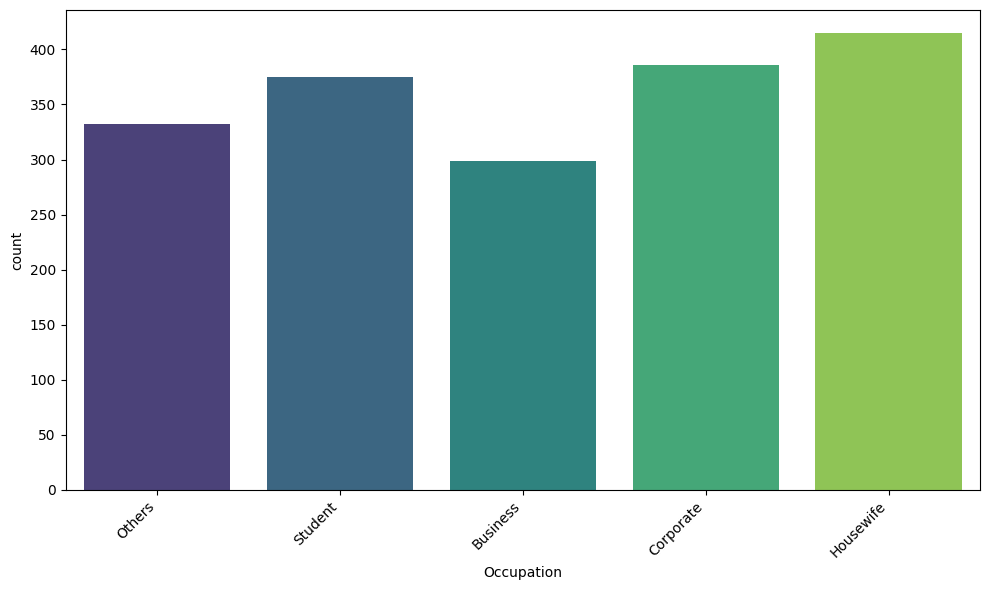

/tmp/ipykernel_1140/1065655851.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=mental_health[mental_health['Country'] == country], x='Occupation', palette='viridis')


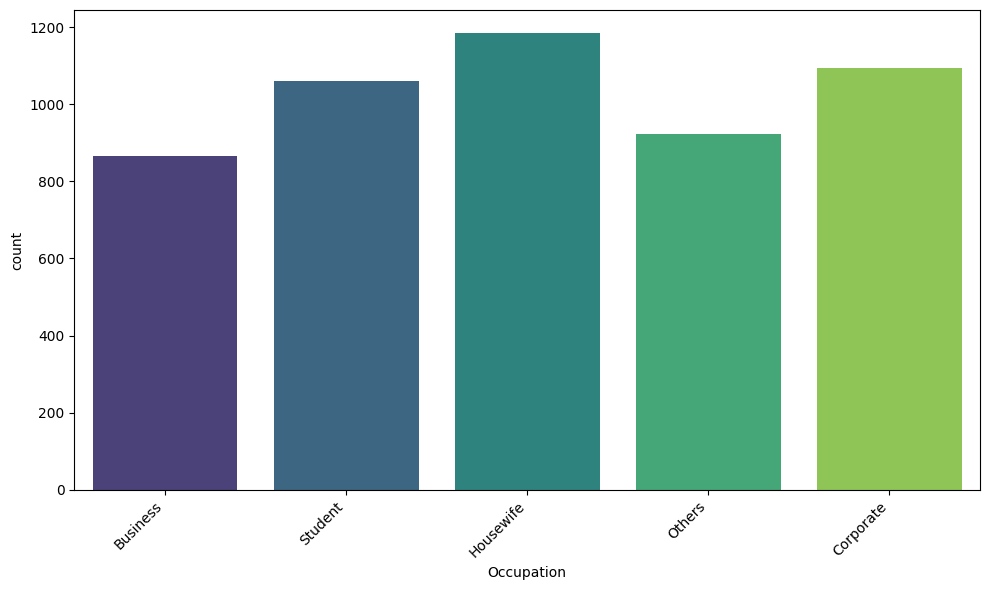

/tmp/ipykernel_1140/1065655851.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=mental_health[mental_health['Country'] == country], x='Occupation', palette='viridis')


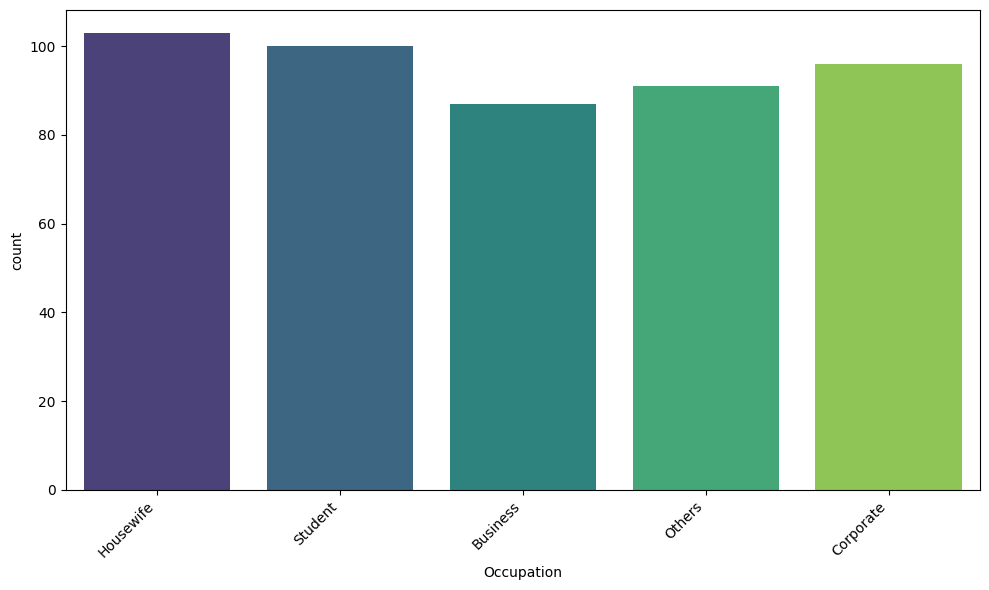

/tmp/ipykernel_1140/1065655851.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=mental_health[mental_health['Country'] == country], x='Occupation', palette='viridis')


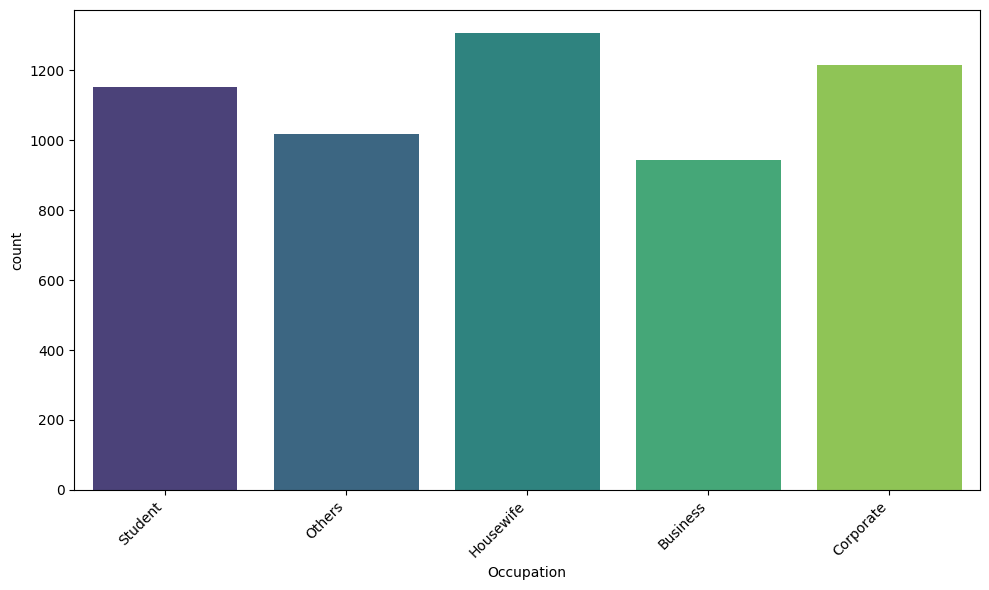

/tmp/ipykernel_1140/1065655851.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=mental_health[mental_health['Country'] == country], x='Occupation', palette='viridis')


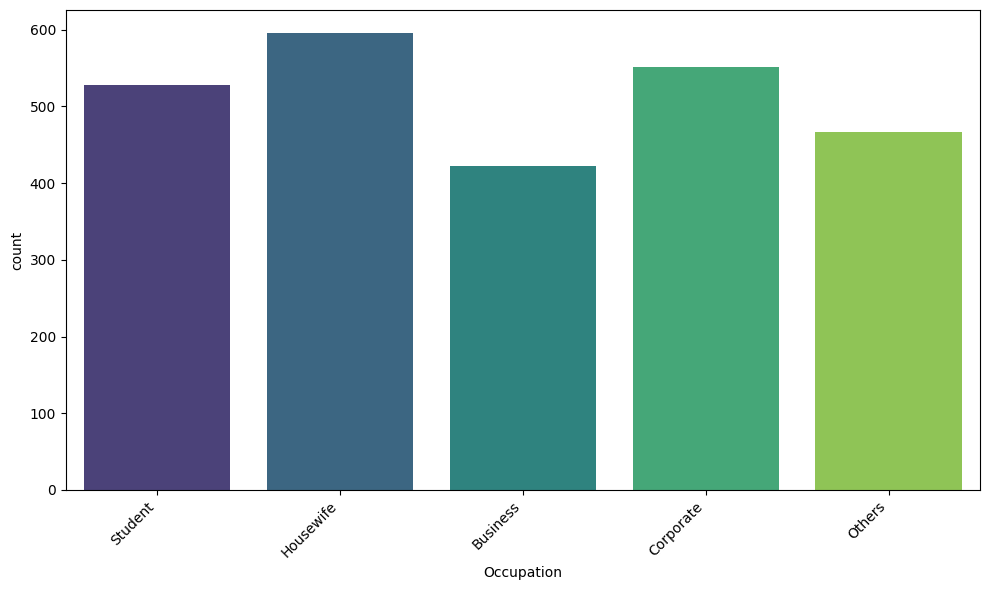

/tmp/ipykernel_1140/1065655851.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=mental_health[mental_health['Country'] == country], x='Occupation', palette='viridis')


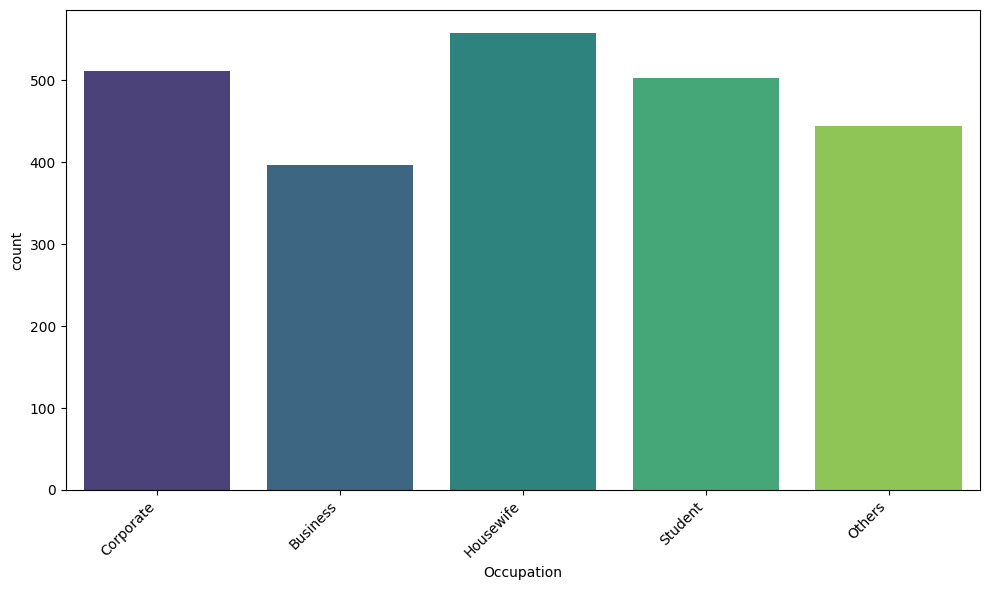

/tmp/ipykernel_1140/1065655851.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=mental_health[mental_health['Country'] == country], x='Occupation', palette='viridis')


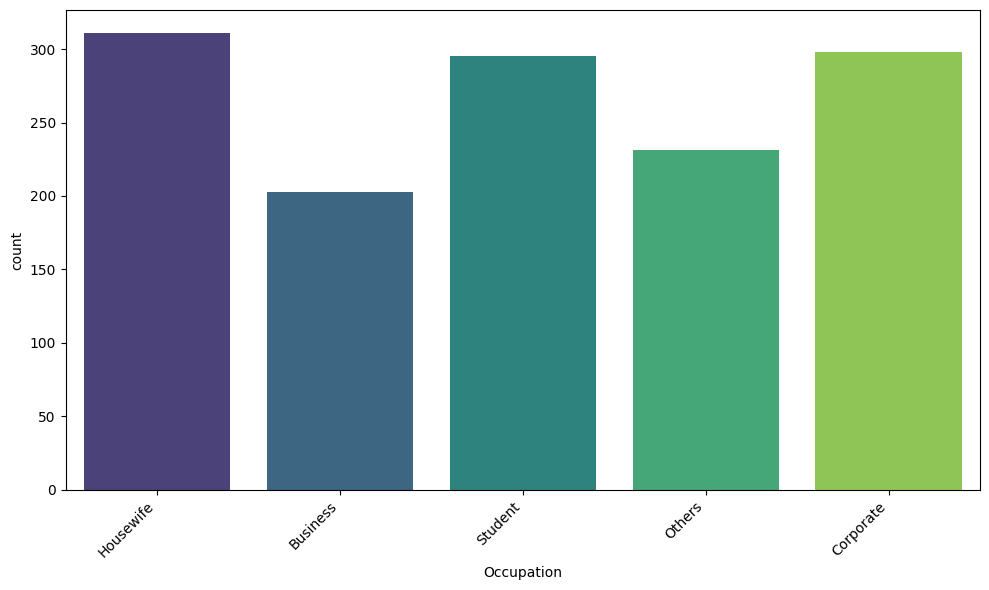

/tmp/ipykernel_1140/1065655851.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=mental_health[mental_health['Country'] == country], x='Occupation', palette='viridis')


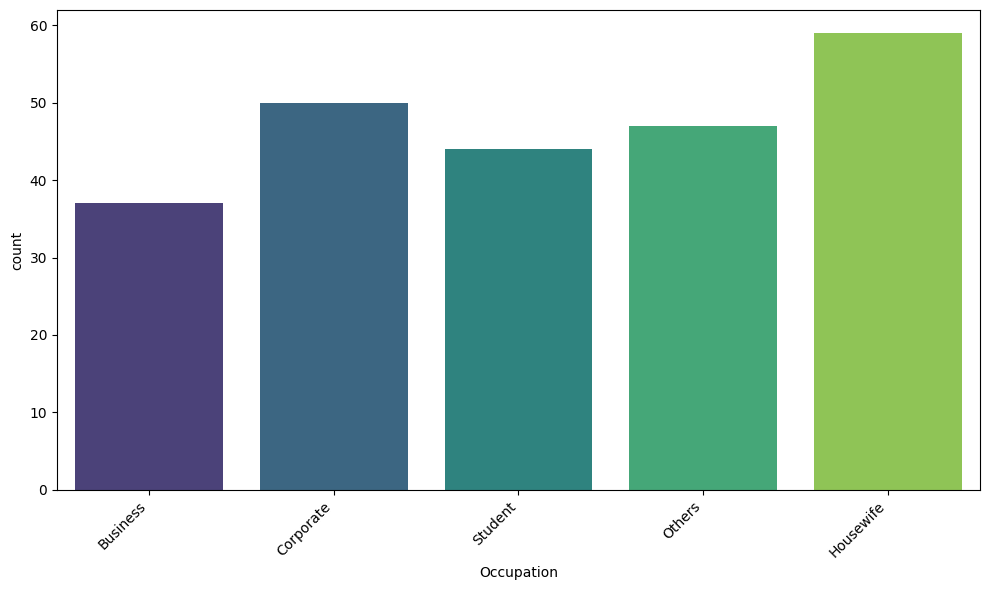

/tmp/ipykernel_1140/1065655851.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=mental_health[mental_health['Country'] == country], x='Occupation', palette='viridis')


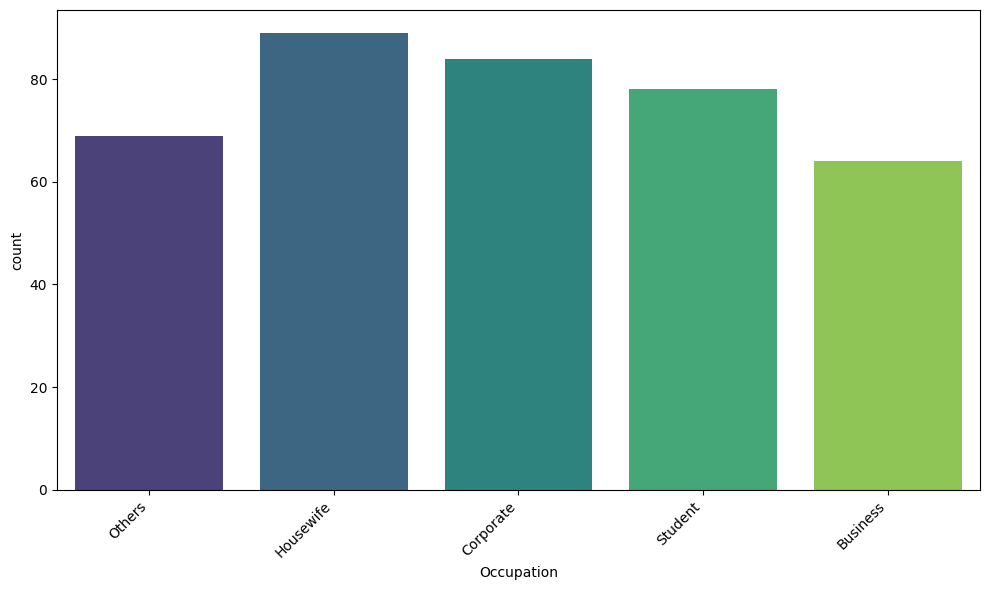

/tmp/ipykernel_1140/1065655851.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=mental_health[mental_health['Country'] == country], x='Occupation', palette='viridis')


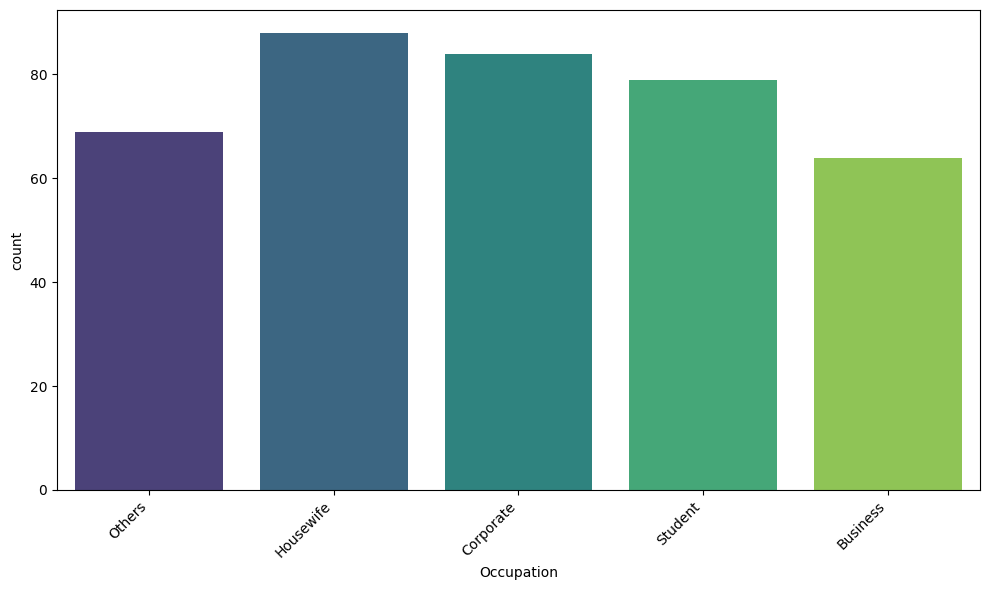

/tmp/ipykernel_1140/1065655851.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=mental_health[mental_health['Country'] == country], x='Occupation', palette='viridis')


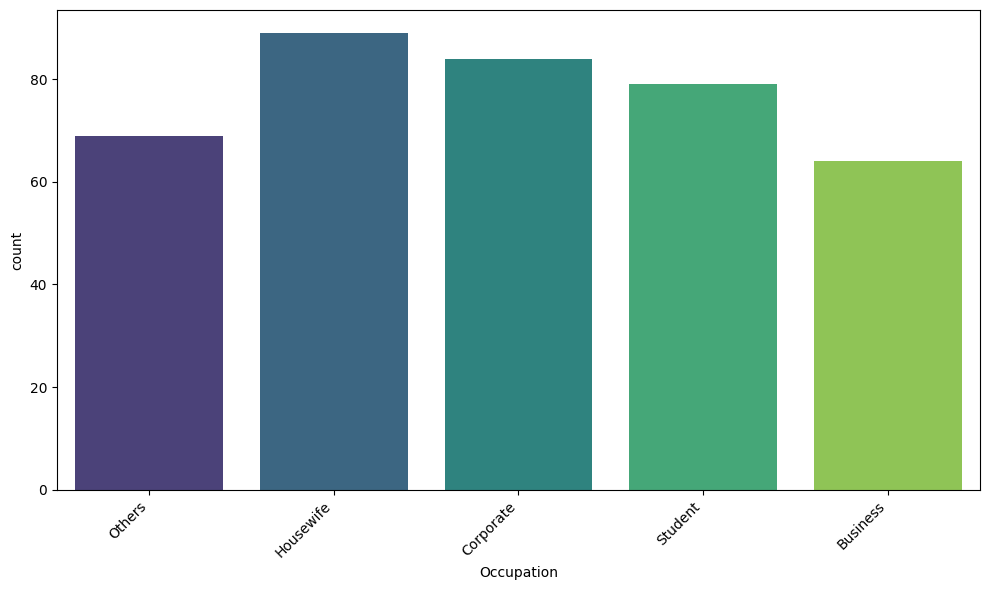

/tmp/ipykernel_1140/1065655851.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=mental_health[mental_health['Country'] == country], x='Occupation', palette='viridis')


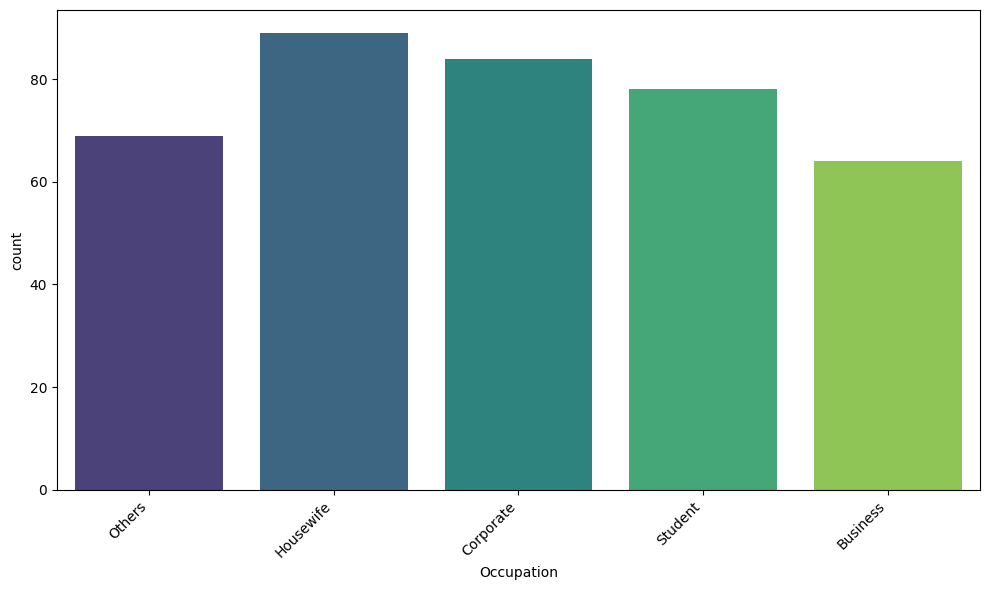

/tmp/ipykernel_1140/1065655851.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=mental_health[mental_health['Country'] == country], x='Occupation', palette='viridis')


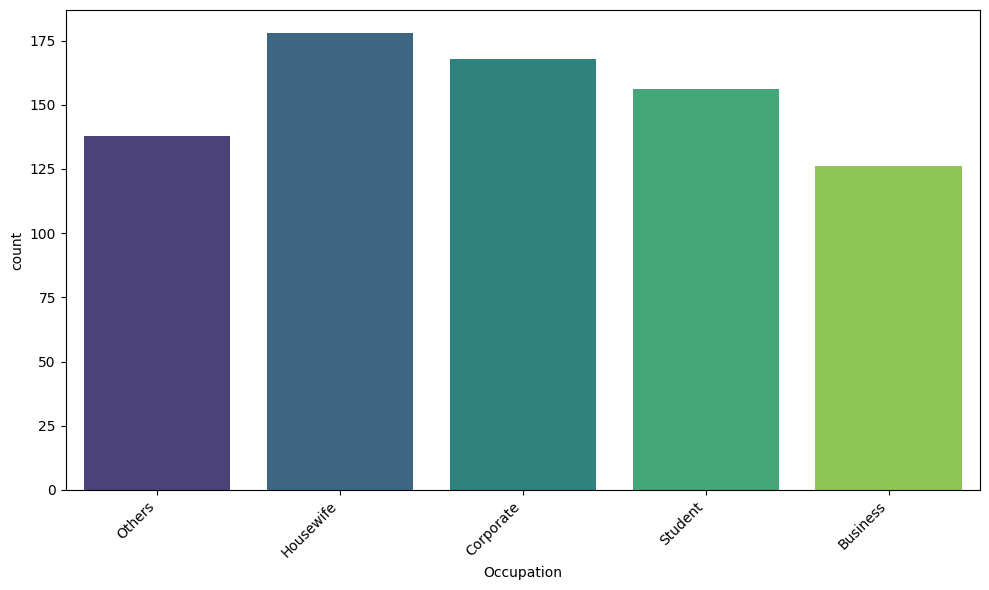

/tmp/ipykernel_1140/1065655851.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=mental_health[mental_health['Country'] == country], x='Occupation', palette='viridis')


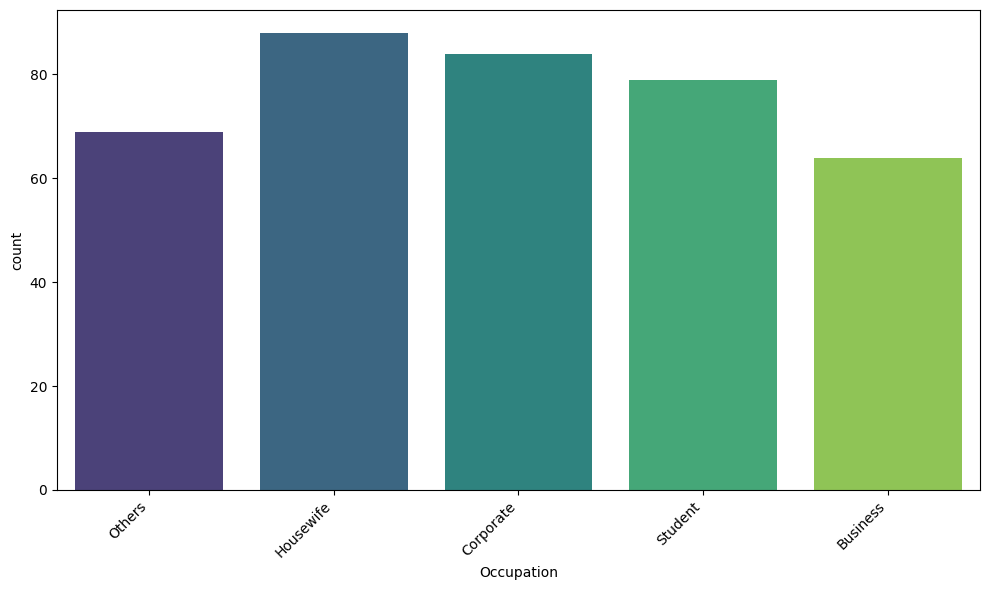

/tmp/ipykernel_1140/1065655851.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=mental_health[mental_health['Country'] == country], x='Occupation', palette='viridis')


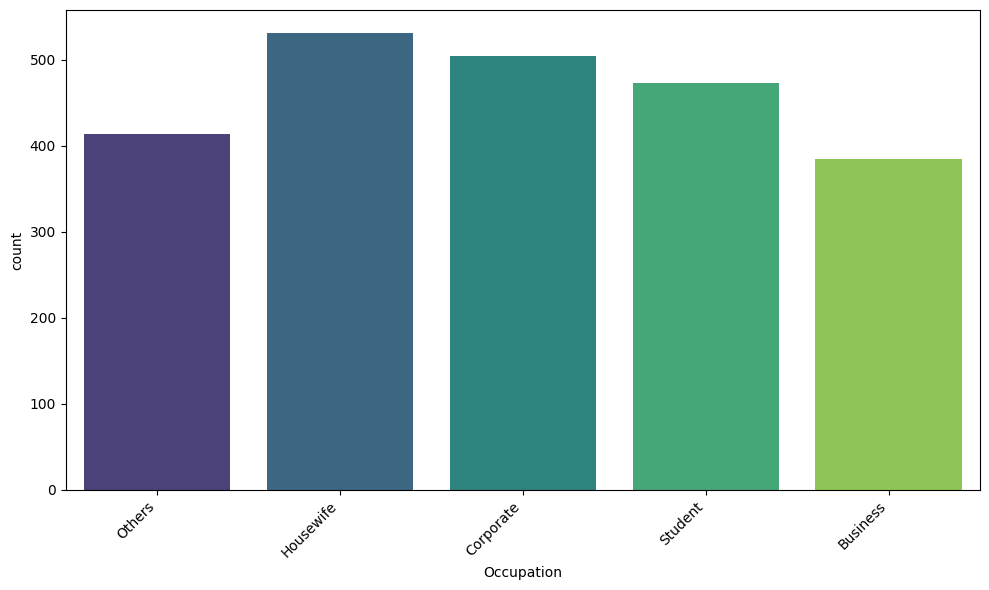

/tmp/ipykernel_1140/1065655851.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=mental_health[mental_health['Country'] == country], x='Occupation', palette='viridis')


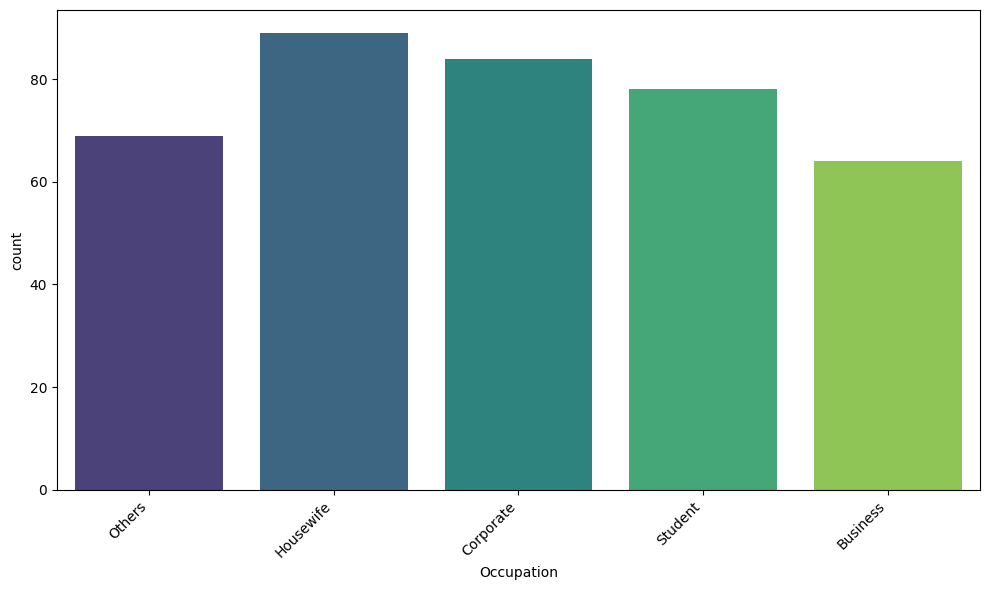

/tmp/ipykernel_1140/1065655851.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=mental_health[mental_health['Country'] == country], x='Occupation', palette='viridis')


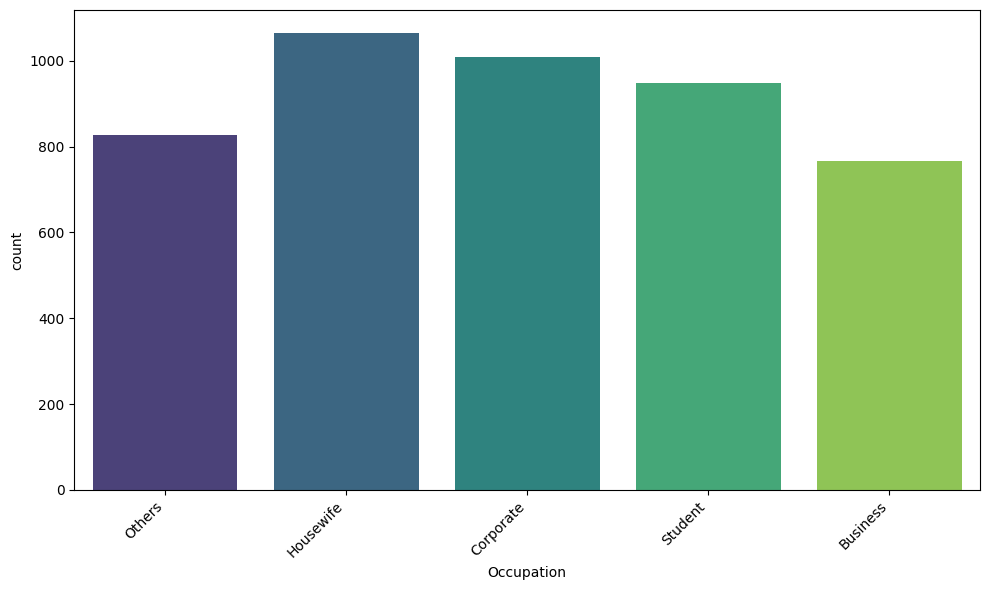

/tmp/ipykernel_1140/1065655851.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=mental_health[mental_health['Country'] == country], x='Occupation', palette='viridis')


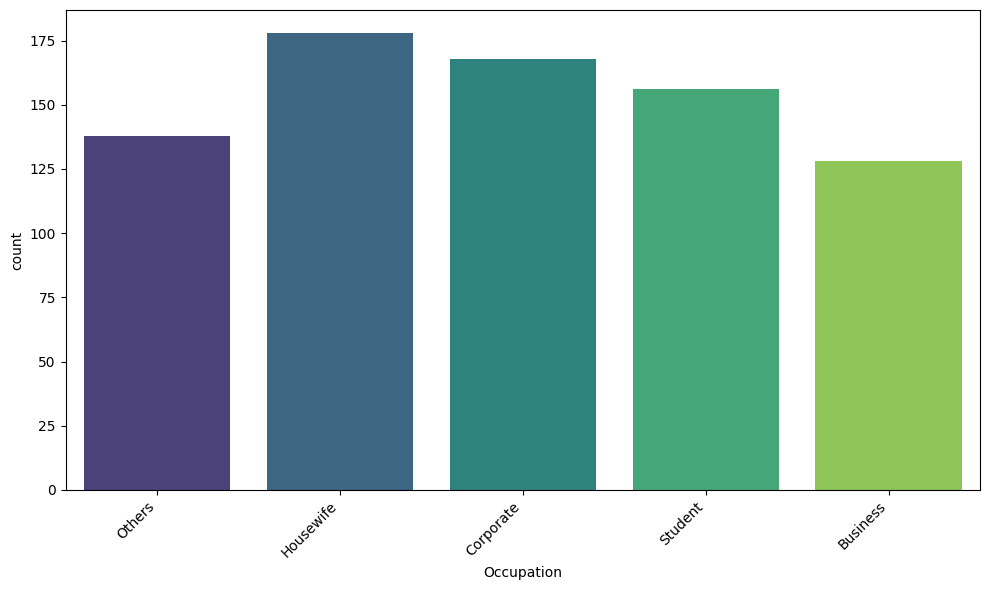

/tmp/ipykernel_1140/1065655851.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=mental_health[mental_health['Country'] == country], x='Occupation', palette='viridis')


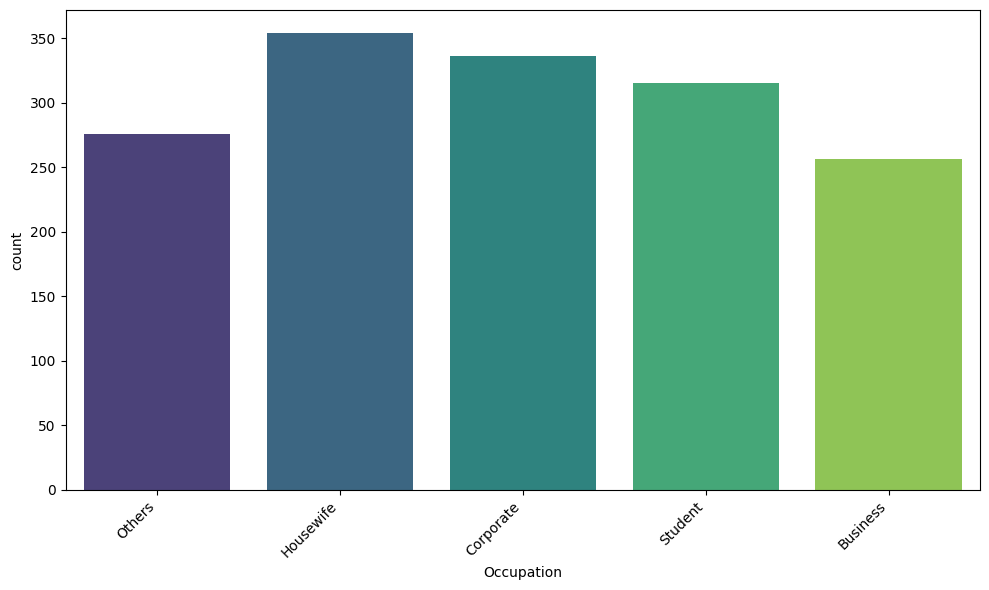

/tmp/ipykernel_1140/1065655851.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=mental_health[mental_health['Country'] == country], x='Occupation', palette='viridis')


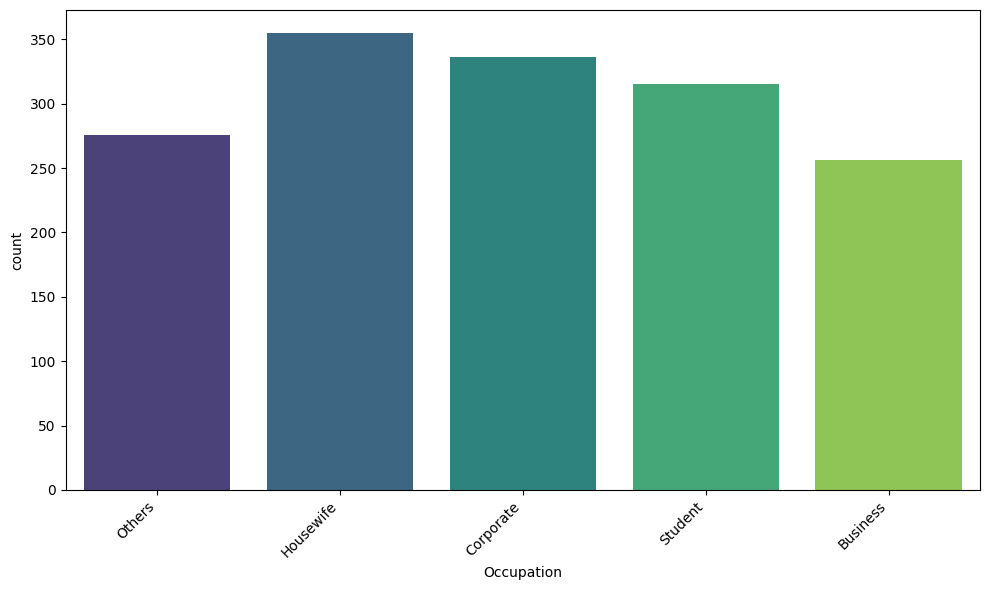

/tmp/ipykernel_1140/1065655851.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=mental_health[mental_health['Country'] == country], x='Occupation', palette='viridis')


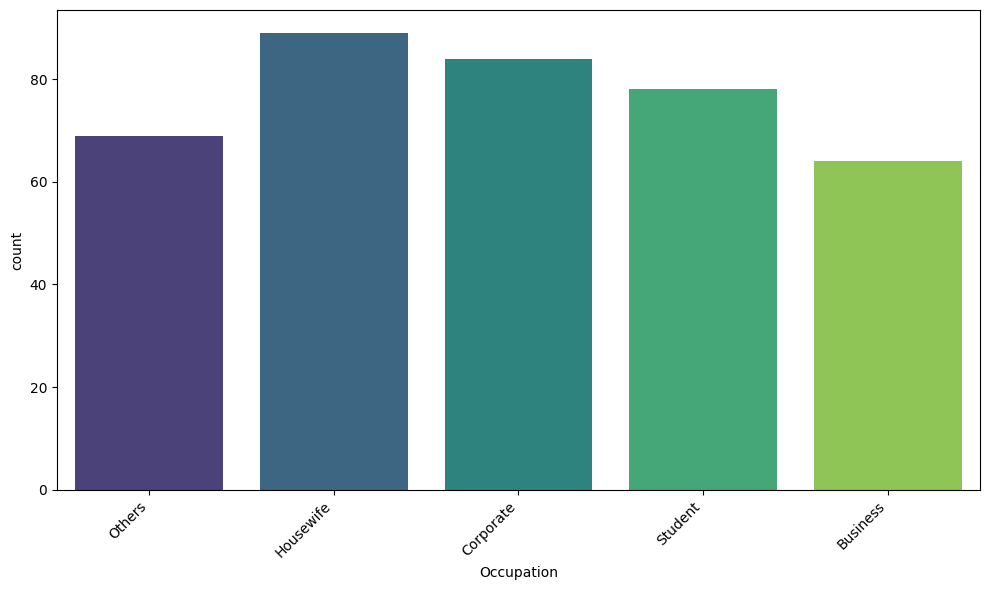

/tmp/ipykernel_1140/1065655851.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=mental_health[mental_health['Country'] == country], x='Occupation', palette='viridis')


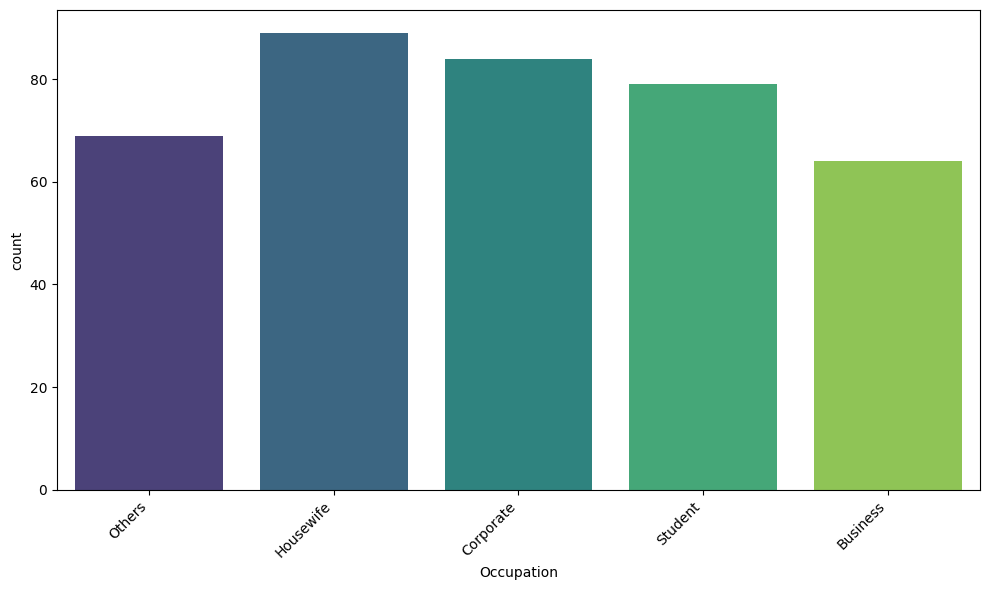

/tmp/ipykernel_1140/1065655851.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=mental_health[mental_health['Country'] == country], x='Occupation', palette='viridis')


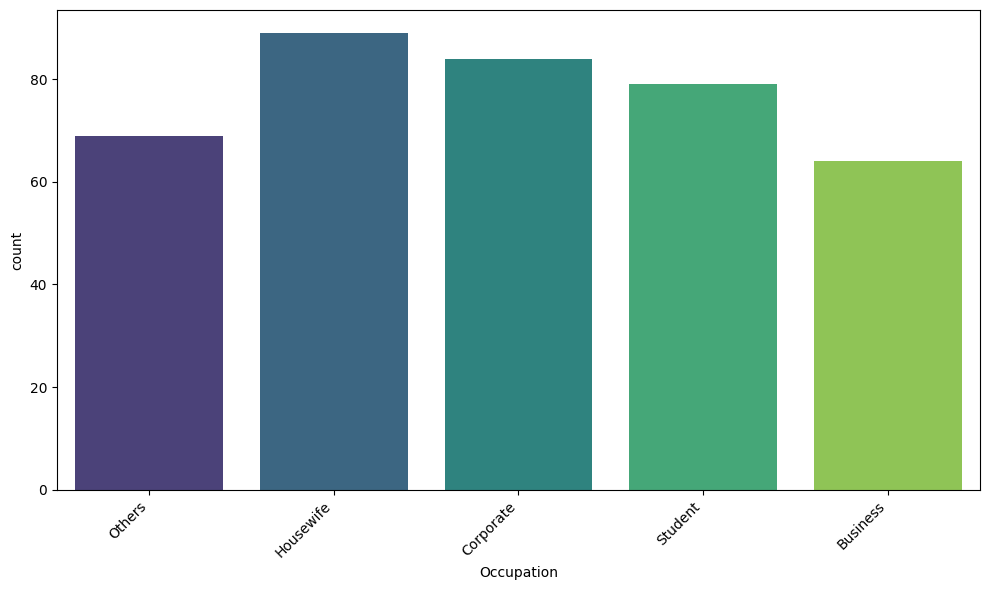

/tmp/ipykernel_1140/1065655851.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=mental_health[mental_health['Country'] == country], x='Occupation', palette='viridis')


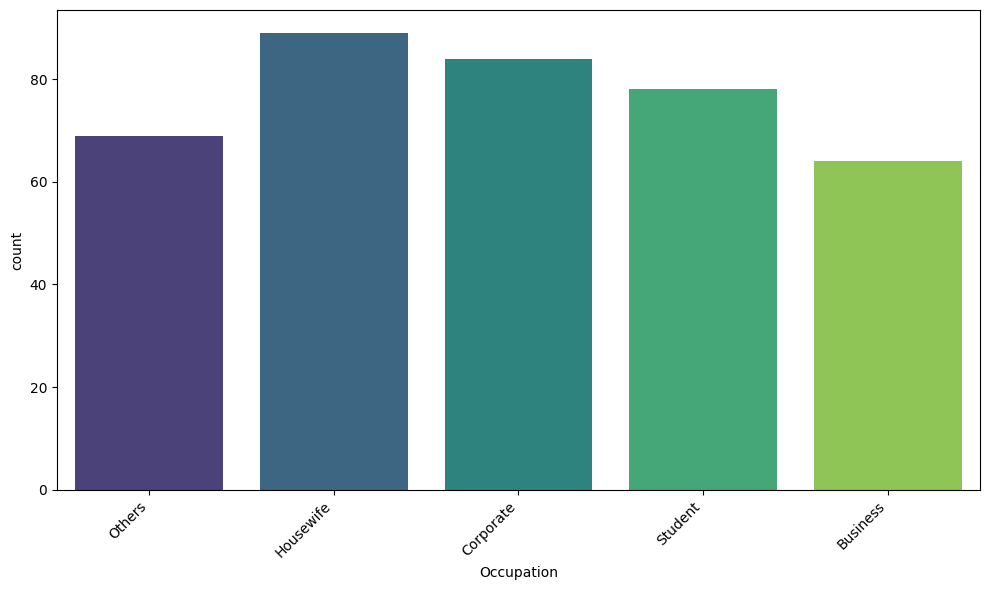

/tmp/ipykernel_1140/1065655851.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=mental_health[mental_health['Country'] == country], x='Occupation', palette='viridis')


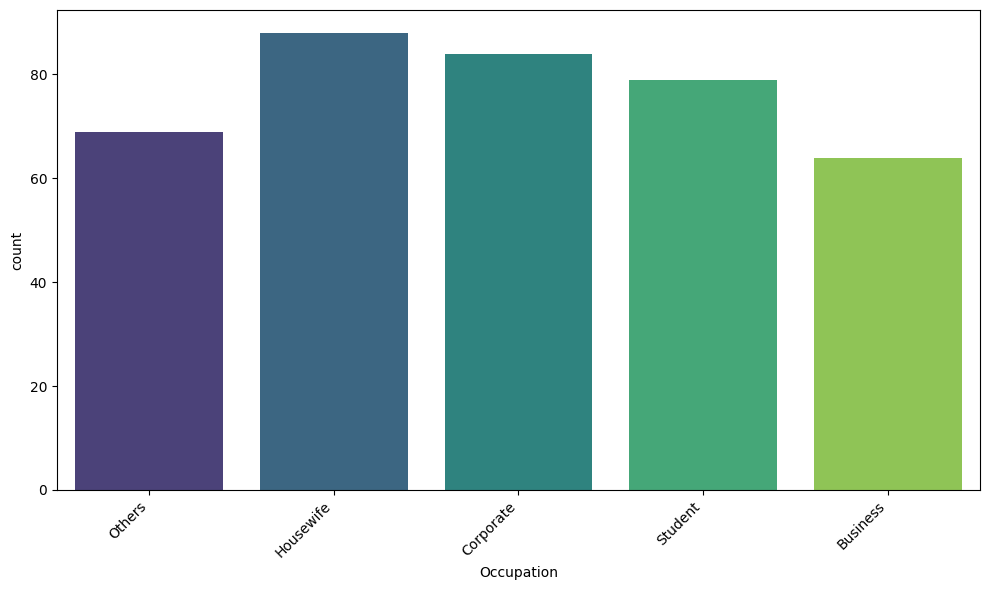

/tmp/ipykernel_1140/1065655851.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=mental_health[mental_health['Country'] == country], x='Occupation', palette='viridis')


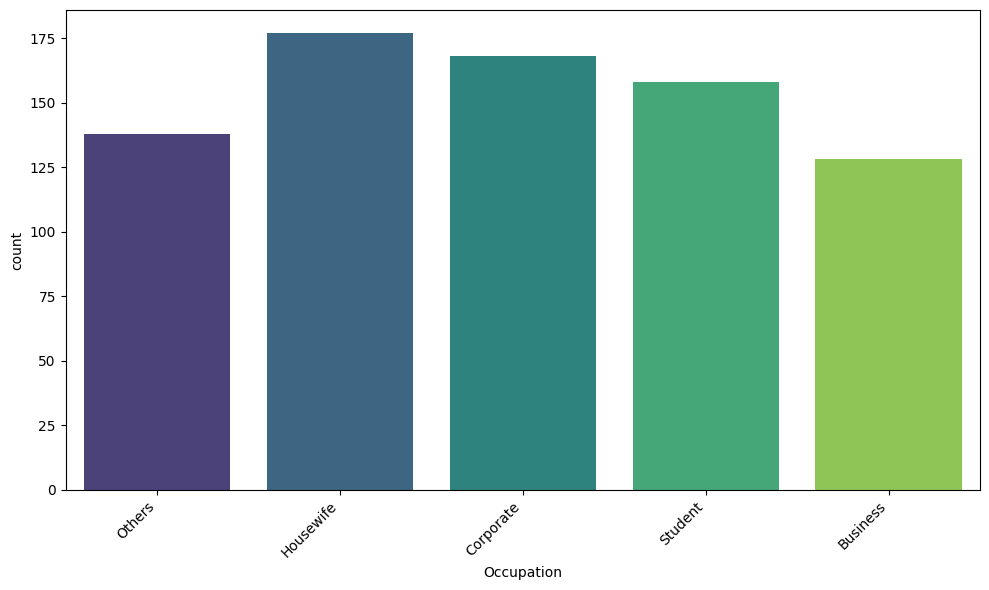

/tmp/ipykernel_1140/1065655851.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=mental_health[mental_health['Country'] == country], x='Occupation', palette='viridis')


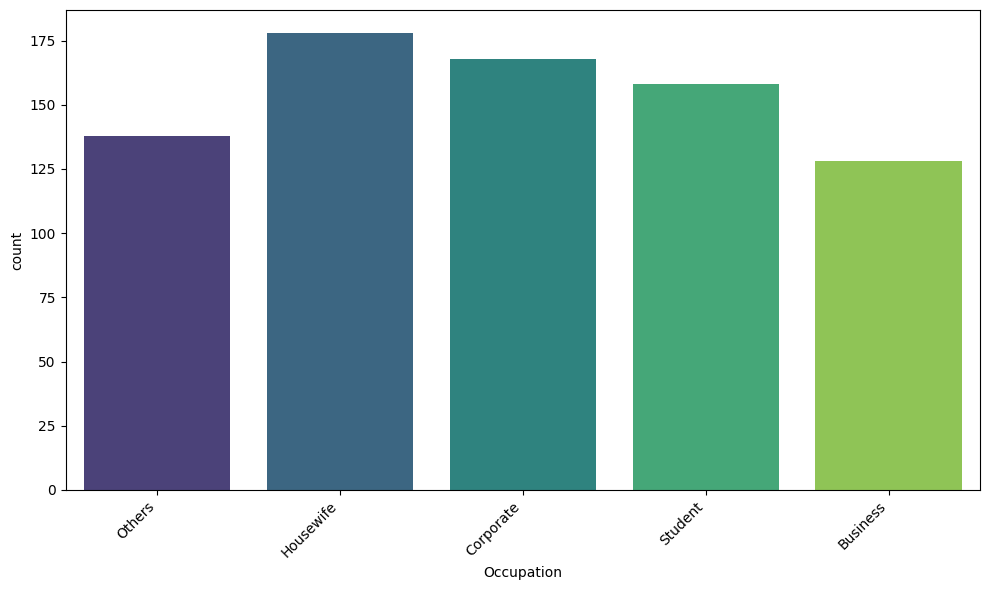

/tmp/ipykernel_1140/1065655851.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=mental_health[mental_health['Country'] == country], x='Occupation', palette='viridis')


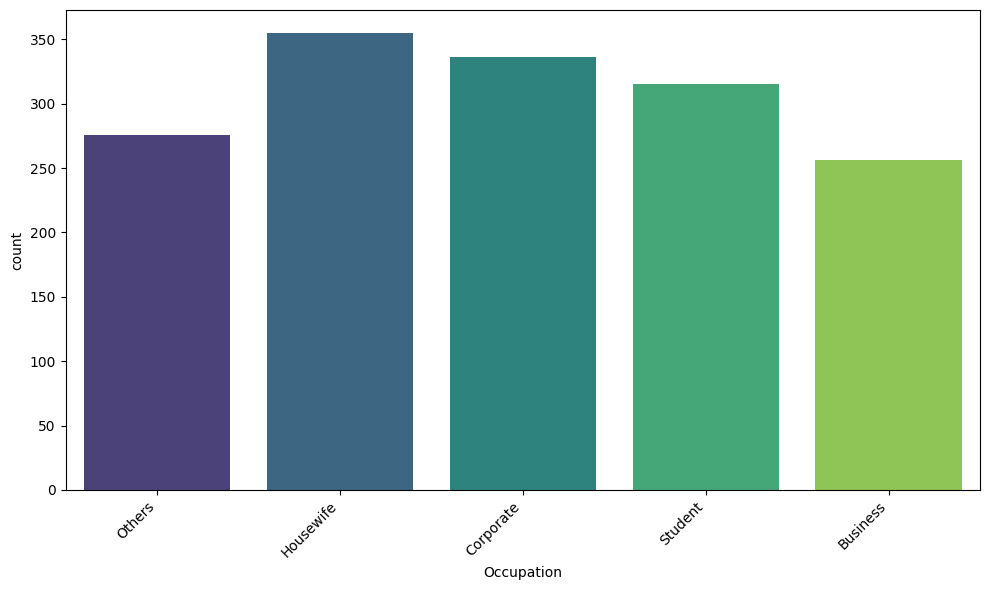

/tmp/ipykernel_1140/1065655851.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=mental_health[mental_health['Country'] == country], x='Occupation', palette='viridis')


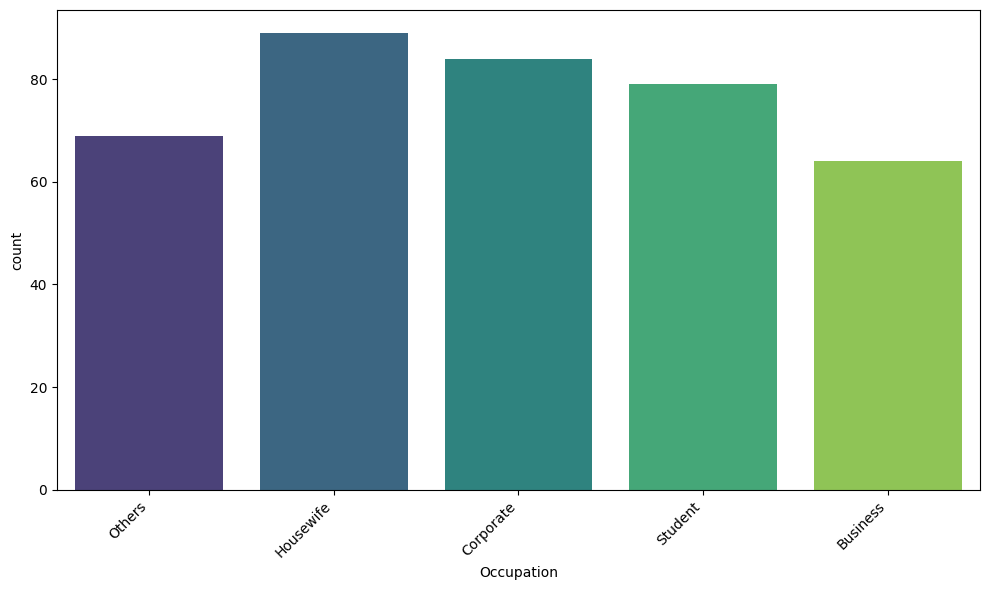

/tmp/ipykernel_1140/1065655851.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=mental_health[mental_health['Country'] == country], x='Occupation', palette='viridis')


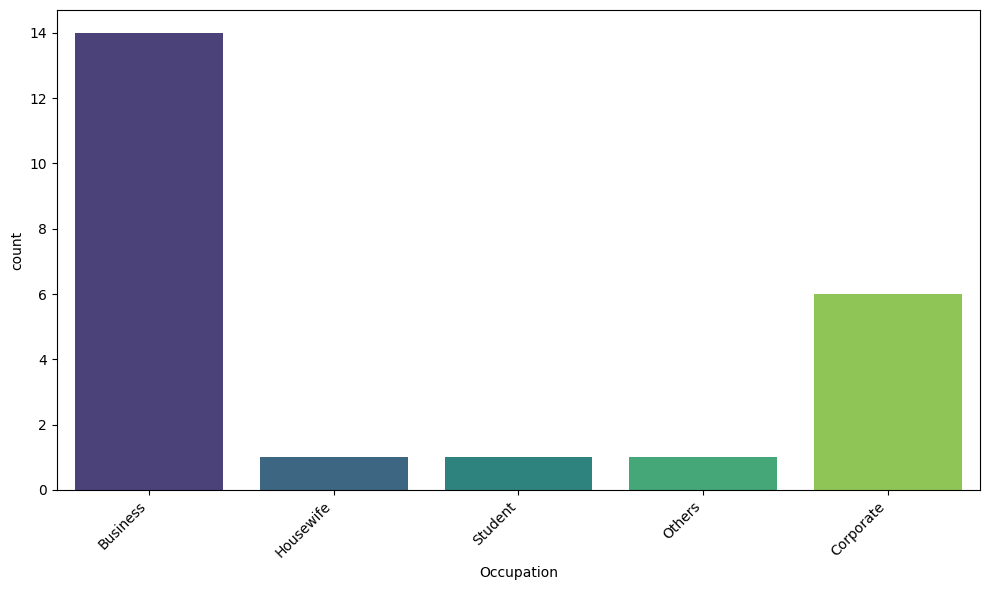

In [161]:
for country in mental_health['Country'].unique():
    plt.figure(figsize=(10, 6))
    sns.countplot(data=mental_health[mental_health['Country'] == country], x='Occupation', palette='viridis')

    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [162]:
mental_health.head()

,Gender,Country,Occupation,SelfEmployed,FamilyHistory,Treatment,DaysIndoors,HabitsChange,MentalHealthHistory,IncreasingStress,...,MentalHealthInterview,CareOptions,Gender_Female,Gender_Male,Occupation_Business,Occupation_Corporate,Occupation_Housewife,Occupation_Others,Occupation_Student,Country_encoded
0,Female,uk,Others,0,1,0,2,0,2,2,...,0,0,1,0,0,0,0,1,0,34
1,Female,usa,Housewife,0,1,0,2,1,1,2,...,0,1,1,0,0,0,1,0,0,35
2,Female,canada,Others,0,0,1,4,1,0,0,...,0,1,1,0,0,0,0,1,0,4
3,Female,canada,Corporate,0,1,1,0,0,1,0,...,0,1,1,0,0,1,0,0,0,4
4,Female,uk,Corporate,0,0,1,4,2,0,1,...,0,1,1,0,0,1,0,0,0,34


<Axes: xlabel='FamilyHistory', ylabel='count'>

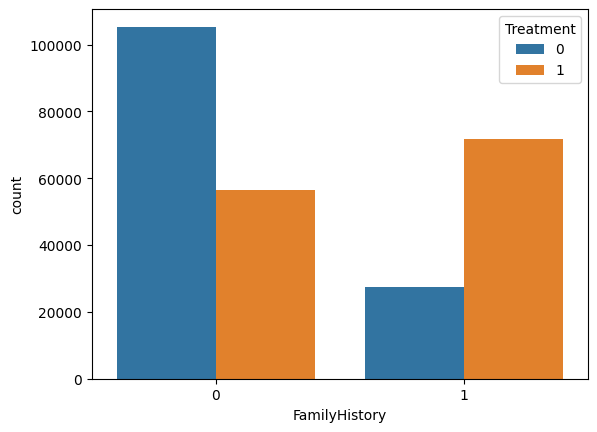

In [163]:
sns.countplot(x='FamilyHistory', hue='Treatment', data=mental_health)

In [164]:
#ppl who dont have family history are conserved in nature

<Axes: xlabel='IncreasingStress', ylabel='count'>

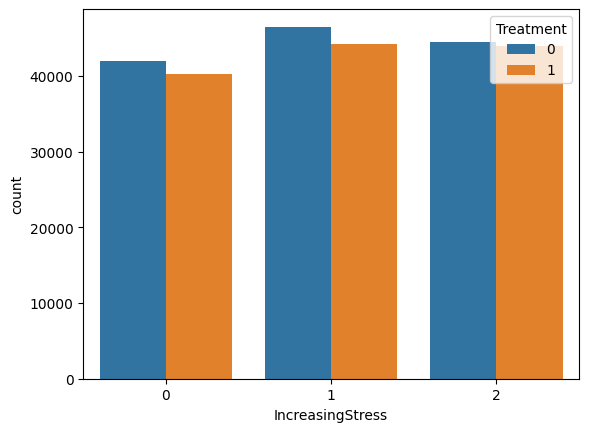

In [165]:
sns.countplot(x='IncreasingStress', hue='Treatment', data=mental_health)

<Axes: xlabel='MoodSwings', ylabel='count'>

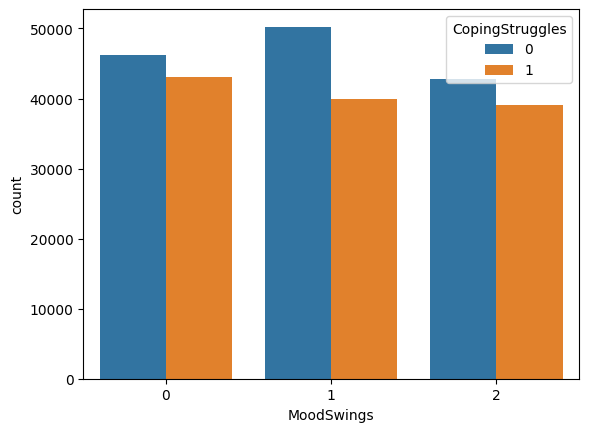

In [166]:
sns.countplot(x='MoodSwings', hue='CopingStruggles', data=mental_health)

<Axes: xlabel='MoodSwings', ylabel='count'>

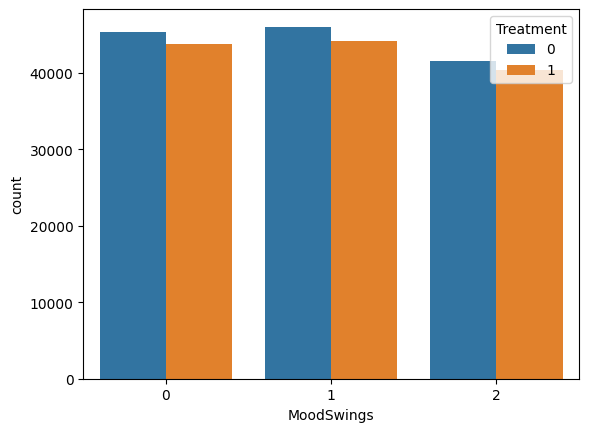

In [167]:
sns.countplot(x='MoodSwings', hue='Treatment', data=mental_health)

In [168]:
#if moodswing is low people has low affinity to take treatment

<Axes: xlabel='SocialWeakness', ylabel='count'>

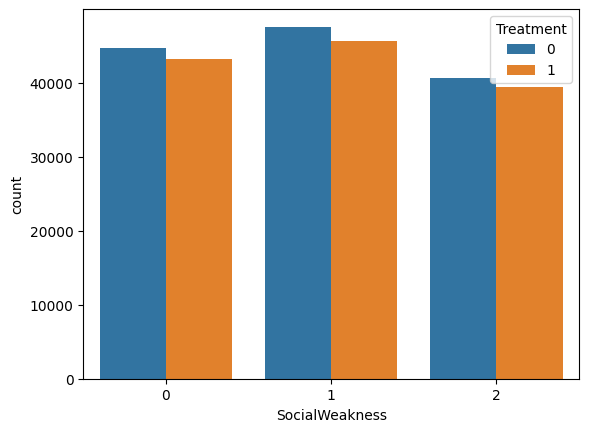

In [169]:
sns.countplot(x='SocialWeakness', hue='Treatment', data=mental_health)

<Axes: xlabel='SocialWeakness', ylabel='count'>

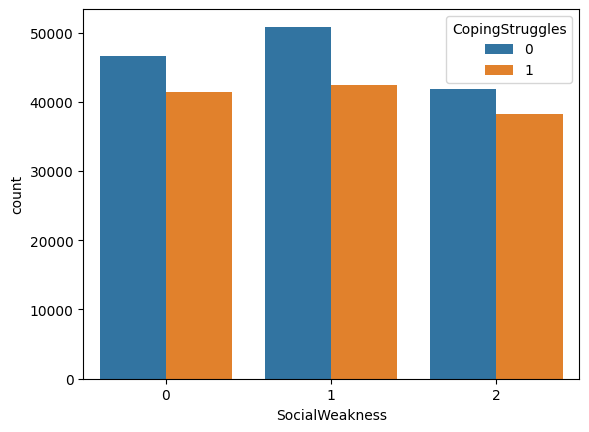

In [170]:
sns.countplot(x='SocialWeakness', hue='CopingStruggles', data=mental_health)

<Axes: xlabel='WorkInterest', ylabel='count'>

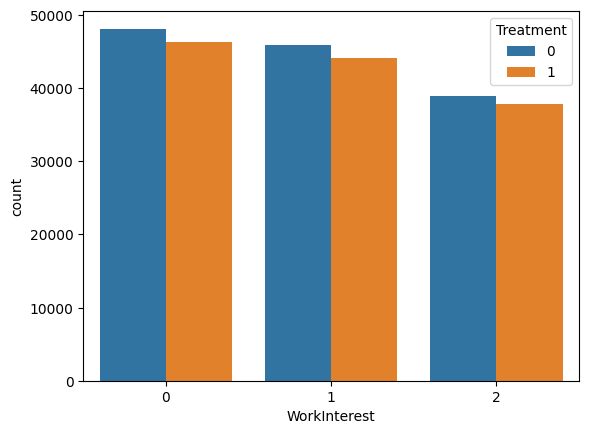

In [171]:
sns.countplot(x='WorkInterest', hue='Treatment', data=mental_health)

In [172]:
#High work interest prevents to take treatment

Treatment                1.000000
FamilyHistory            0.362023
CareOptions              0.250630
Gender_Female            0.078486
Country_encoded          0.065142
SelfEmployed             0.036804
CopingStruggles          0.006716
IncreasingStress         0.005459
Occupation_Student       0.002881
WorkInterest             0.001896
Occupation_Business      0.001830
Occupation_Others        0.001746
MentalHealthHistory      0.001367
MoodSwings               0.001262
DaysIndoors              0.000908
SocialWeakness          -0.000076
SocialWeakness.1        -0.000076
Occupation_Housewife    -0.000619
HabitsChange            -0.001524
Occupation_Corporate    -0.005534
MentalHealthInterview   -0.054190
Gender_Male             -0.078486
Name: Treatment, dtype: float64


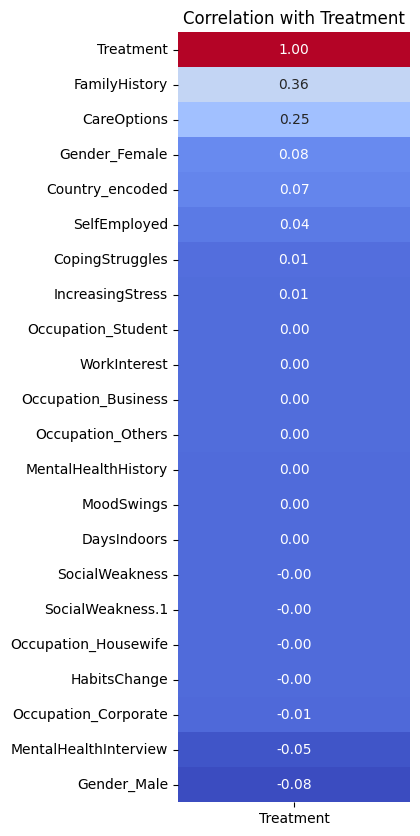

In [173]:
numerical_mental_health = mental_health.select_dtypes(include=['float64', 'int64', 'bool'])
correlations = numerical_mental_health.corr()['Treatment'].sort_values(ascending=False)
print(correlations)

plt.figure(figsize=(3, 10))
sns.heatmap(correlations.to_frame(), annot=True, cmap='coolwarm', fmt=".2f", cbar=False)
plt.title('Correlation with Treatment')
plt.yticks(rotation=0)
plt.show()

# Feature Engineering

In [174]:
#Gender male will be dropped #occupations will be dropped

In [175]:
mental_health.head()

,Gender,Country,Occupation,SelfEmployed,FamilyHistory,Treatment,DaysIndoors,HabitsChange,MentalHealthHistory,IncreasingStress,...,MentalHealthInterview,CareOptions,Gender_Female,Gender_Male,Occupation_Business,Occupation_Corporate,Occupation_Housewife,Occupation_Others,Occupation_Student,Country_encoded
0,Female,uk,Others,0,1,0,2,0,2,2,...,0,0,1,0,0,0,0,1,0,34
1,Female,usa,Housewife,0,1,0,2,1,1,2,...,0,1,1,0,0,0,1,0,0,35
2,Female,canada,Others,0,0,1,4,1,0,0,...,0,1,1,0,0,0,0,1,0,4
3,Female,canada,Corporate,0,1,1,0,0,1,0,...,0,1,1,0,0,1,0,0,0,4
4,Female,uk,Corporate,0,0,1,4,2,0,1,...,0,1,1,0,0,1,0,0,0,34


In [176]:
mental_health_updated=mental_health

In [177]:
mental_health_updated.head()

,Gender,Country,Occupation,SelfEmployed,FamilyHistory,Treatment,DaysIndoors,HabitsChange,MentalHealthHistory,IncreasingStress,...,MentalHealthInterview,CareOptions,Gender_Female,Gender_Male,Occupation_Business,Occupation_Corporate,Occupation_Housewife,Occupation_Others,Occupation_Student,Country_encoded
0,Female,uk,Others,0,1,0,2,0,2,2,...,0,0,1,0,0,0,0,1,0,34
1,Female,usa,Housewife,0,1,0,2,1,1,2,...,0,1,1,0,0,0,1,0,0,35
2,Female,canada,Others,0,0,1,4,1,0,0,...,0,1,1,0,0,0,0,1,0,4
3,Female,canada,Corporate,0,1,1,0,0,1,0,...,0,1,1,0,0,1,0,0,0,4
4,Female,uk,Corporate,0,0,1,4,2,0,1,...,0,1,1,0,0,1,0,0,0,34


In [178]:
mental_health_updated['Early stage'] = mental_health_updated['Occupation_Student'].map({0: 0, 1: 1})
mental_health_updated['Early stage'].value_counts()

,count
Early stage,
0,207141
1,54208


<Axes: xlabel='Early stage', ylabel='count'>

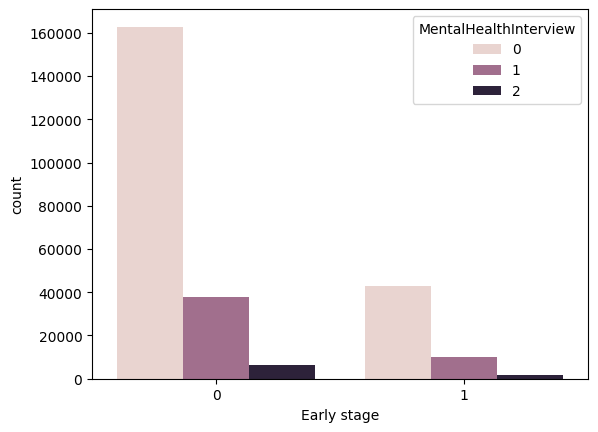

In [179]:
sns.countplot(x='Early stage',hue='MentalHealthInterview',data=mental_health_updated)

<Axes: xlabel='Early stage', ylabel='count'>

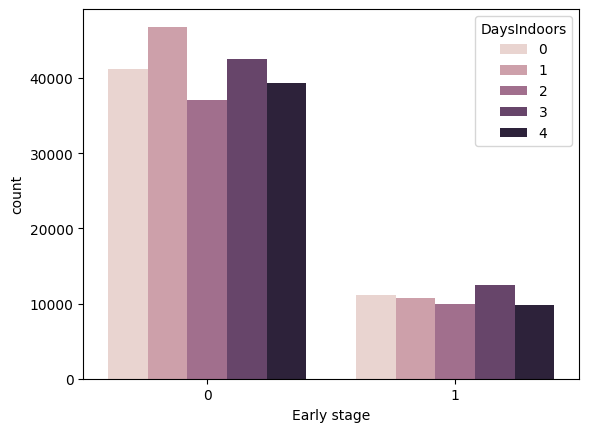

In [180]:
sns.countplot(x='Early stage',hue='DaysIndoors',data=mental_health_updated)

In [181]:
early_stage_days_indoors_percentages = mental_health_updated[mental_health_updated['Early stage'] == 1]['DaysIndoors'].value_counts(normalize=True) * 100
print("DaysIndoors percentages for Early Stage individuals:")
print(early_stage_days_indoors_percentages)

overall_days_indoors_percentages = mental_health_updated['DaysIndoors'].value_counts(normalize=True) * 100
print("\nOverall DaysIndoors percentages:")
print(overall_days_indoors_percentages)

DaysIndoors percentages for Early Stage individuals:
DaysIndoors
3    22.956021
0    20.592901
1    19.888208
2    18.364448
4    18.198421
Name: proportion, dtype: float64

Overall DaysIndoors percentages:
DaysIndoors
1    22.041026
3    21.042361
0    20.052879
4    18.846829
2    18.016905
Name: proportion, dtype: float64


In [182]:
#early stage patients don't want to go out often

<Axes: xlabel='Early stage', ylabel='count'>

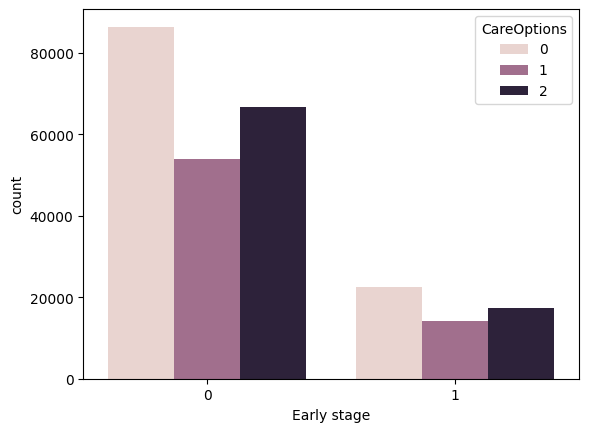

In [183]:
sns.countplot(x='Early stage',hue='CareOptions',data=mental_health_updated)

In [184]:
early_stage_days_CareOptions_percentages = mental_health_updated[mental_health_updated['Early stage'] == 1]['CareOptions'].value_counts(normalize=True) * 100
print("CareOptions percentages for Early Stage individuals:")
print(early_stage_days_CareOptions_percentages)

overall_days_CareOptions_percentages = mental_health_updated['CareOptions'].value_counts(normalize=True) * 100
print("\nOverall CareOptions percentages:")
print(overall_days_CareOptions_percentages)

CareOptions percentages for Early Stage individuals:
CareOptions
0    41.519702
2    32.235094
1    26.245204
Name: proportion, dtype: float64

Overall CareOptions percentages:
CareOptions
0    41.695970
2    32.186081
1    26.117950
Name: proportion, dtype: float64


In [185]:
mental_health_updated.head()

,Gender,Country,Occupation,SelfEmployed,FamilyHistory,Treatment,DaysIndoors,HabitsChange,MentalHealthHistory,IncreasingStress,...,CareOptions,Gender_Female,Gender_Male,Occupation_Business,Occupation_Corporate,Occupation_Housewife,Occupation_Others,Occupation_Student,Country_encoded,Early stage
0,Female,uk,Others,0,1,0,2,0,2,2,...,0,1,0,0,0,0,1,0,34,0
1,Female,usa,Housewife,0,1,0,2,1,1,2,...,1,1,0,0,0,1,0,0,35,0
2,Female,canada,Others,0,0,1,4,1,0,0,...,1,1,0,0,0,0,1,0,4,0
3,Female,canada,Corporate,0,1,1,0,0,1,0,...,1,1,0,0,1,0,0,0,4,0
4,Female,uk,Corporate,0,0,1,4,2,0,1,...,1,1,0,0,1,0,0,0,34,0


In [186]:
mental_health['CopingStruggles'].value_counts()

,count
CopingStruggles,
0,139251
1,122098


In [187]:
mental_health_updated['StressScore']=0.5*mental_health_updated['IncreasingStress']+mental_health_updated['CopingStruggles']+0.5*mental_health_updated['MoodSwings']+0.5*mental_health_updated['HabitsChange']+0.5*mental_health_updated['SocialWeakness']

<Axes: xlabel='StressScore', ylabel='Count'>

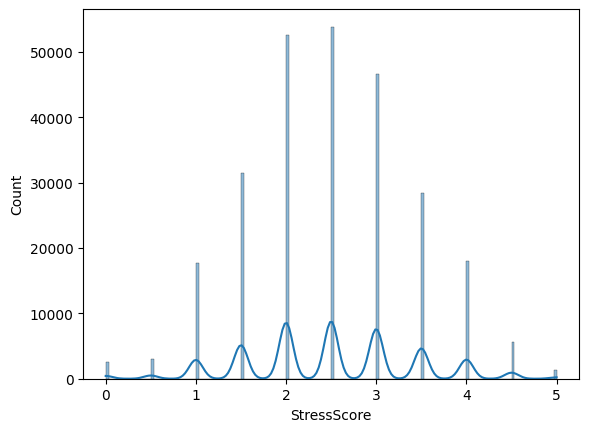

In [188]:
sns.histplot(mental_health_updated['StressScore'], kde=True)

In [189]:
mental_health_updated.shape

(261349, 27)

In [190]:
mental_health_updated['StressScore'].describe()

,StressScore
count,261349.000000
mean,2.486696
std,0.926567
min,0.000000
25%,2.000000
50%,2.500000
75%,3.000000
max,5.000000


In [191]:
mental_health_updated['Isolation_env']=0.25*mental_health_updated['DaysIndoors']+0.5*mental_health_updated['SocialWeakness']

<Axes: xlabel='Isolation_env', ylabel='Count'>

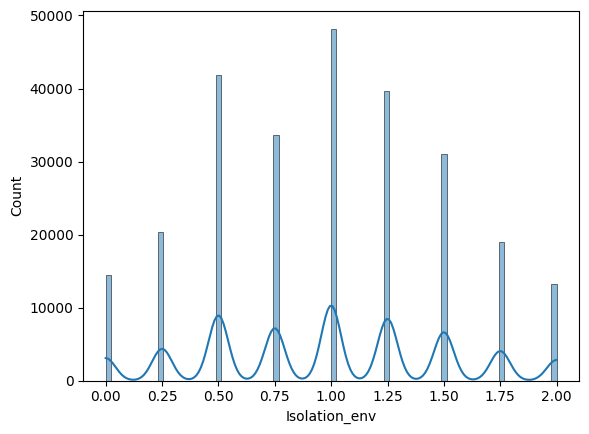

In [192]:
sns.histplot(mental_health_updated['Isolation_env'],kde=True)

In [193]:
mental_health_updated['Isolation_env'].describe()

,Isolation_env
count,261349.000000
mean,0.976484
std,0.526568
min,0.000000
25%,0.500000
50%,1.000000
75%,1.250000
max,2.000000


In [194]:
mental_health_updated.to_csv('mental_health_updated.csv', index=False)

# Train Test Split

In [195]:
mental_health_model=mental_health_updated.drop(columns=['Gender','Country','Occupation','SocialWeakness.1'])

In [196]:
mental_health_model.head()

,SelfEmployed,FamilyHistory,Treatment,DaysIndoors,HabitsChange,MentalHealthHistory,IncreasingStress,MoodSwings,SocialWeakness,CopingStruggles,...,Gender_Male,Occupation_Business,Occupation_Corporate,Occupation_Housewife,Occupation_Others,Occupation_Student,Country_encoded,Early stage,StressScore,Isolation_env
0,0,1,0,2,0,2,2,2,0,1,...,0,0,0,0,1,0,34,0,3.0,0.5
1,0,1,0,2,1,1,2,2,1,1,...,0,0,0,1,0,0,35,0,4.0,1.0
2,0,0,1,4,1,0,0,1,0,0,...,0,0,0,0,1,0,4,0,1.0,1.0
3,0,1,1,0,0,1,0,1,0,0,...,0,0,1,0,0,0,4,0,0.5,0.0
4,0,0,1,4,2,0,1,1,1,0,...,0,0,1,0,0,0,34,0,2.5,1.5


In [197]:
X = mental_health_model.drop(columns=['Treatment'])
y = mental_health_model['Treatment']

# 40% temp (test + validation)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Training set shape: {X_train.shape}")
print(f"Validation set shape: {X_val.shape}")
print(f"Test set shape: {X_test.shape}")

Training set shape: (156809, 23)
Validation set shape: (52270, 23)
Test set shape: (52270, 23)


In [198]:
import joblib

feature_columns = X.columns.tolist()

joblib.dump(
    feature_columns,
    'feature_columns.pkl'
)

['feature_columns.pkl']

# Classification

In [199]:
rf=RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

In [200]:
y_val_pred = rf.predict(X_val)
print("Validation Accuracy:")
print(accuracy_score(y_val, y_val_pred))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred))

Validation Accuracy:
0.7184618327912761

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.71      0.72     26614
           1       0.71      0.73      0.72     25656

    accuracy                           0.72     52270
   macro avg       0.72      0.72      0.72     52270
weighted avg       0.72      0.72      0.72     52270



In [201]:
y_test_pred = rf.predict(X_test)
print("Validation Accuracy:")
print(accuracy_score(y_test, y_test_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

Validation Accuracy:
0.7139276831834704

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.70      0.71     26635
           1       0.70      0.73      0.71     25635

    accuracy                           0.71     52270
   macro avg       0.71      0.71      0.71     52270
weighted avg       0.71      0.71      0.71     52270



In [202]:
importance = rf.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nFeature Importance:")
print(feature_importance)


Feature Importance:
                  Feature  Importance
19        Country_encoded    0.259018
1           FamilyHistory    0.233957
11            CareOptions    0.208846
10  MentalHealthInterview    0.059535
0            SelfEmployed    0.041230
21            StressScore    0.024692
22          Isolation_env    0.021395
2             DaysIndoors    0.017417
9            WorkInterest    0.016341
4     MentalHealthHistory    0.015392
6              MoodSwings    0.014545
3            HabitsChange    0.013877
5        IncreasingStress    0.013581
7          SocialWeakness    0.010789
16   Occupation_Housewife    0.008638
8         CopingStruggles    0.007887
13            Gender_Male    0.006504
12          Gender_Female    0.006270
15   Occupation_Corporate    0.004643
17      Occupation_Others    0.004542
14    Occupation_Business    0.004489
20            Early stage    0.003288
18     Occupation_Student    0.003123


In [203]:
xgb=XGBClassifier(n_estimators=300,
    learning_rate=0.05,
    max_depth=5

)
xgb.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [204]:
y_pred_xgb = xgb.predict(X_test)
print("Accuracy:",
      accuracy_score(y_test, y_pred_xgb))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_xgb
))

Accuracy: 0.7642242203941075

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.72      0.76     26635
           1       0.73      0.81      0.77     25635

    accuracy                           0.76     52270
   macro avg       0.77      0.77      0.76     52270
weighted avg       0.77      0.76      0.76     52270



In [205]:
importancexgb_df = pd.DataFrame({

    "Feature": X_train.columns,

    "Importance": xgb.feature_importances_

})

importancexgb_df = importancexgb_df.sort_values(

    by="Importance",

    ascending=False
)

print(importancexgb_df)

                  Feature  Importance
1           FamilyHistory    0.465484
11            CareOptions    0.168904
0            SelfEmployed    0.095312
10  MentalHealthInterview    0.079055
19        Country_encoded    0.077709
16   Occupation_Housewife    0.045514
12          Gender_Female    0.038656
7          SocialWeakness    0.003095
5        IncreasingStress    0.002746
6              MoodSwings    0.002703
18     Occupation_Student    0.002500
22          Isolation_env    0.002490
21            StressScore    0.002194
4     MentalHealthHistory    0.002166
9            WorkInterest    0.002091
8         CopingStruggles    0.002085
2             DaysIndoors    0.001868
15   Occupation_Corporate    0.001814
17      Occupation_Others    0.001378
3            HabitsChange    0.001151
14    Occupation_Business    0.001084
13            Gender_Male    0.000000
20            Early stage    0.000000


In [206]:
import joblib

joblib.dump(
    xgb,
    'mental_health_model.pkl'
)

['mental_health_model.pkl']

In [207]:
gb=GradientBoostingClassifier(n_estimators=100,
    learning_rate=0.05,
    max_depth=5

)
gb.fit(X_train,y_train)

GradientBoostingClassifier(learning_rate=0.05, max_depth=5)

In [208]:
y_pred_gb = gb.predict(X_test)
print("Accuracy:",
      accuracy_score(y_test, y_pred_gb))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_gb
))

Accuracy: 0.757241247369428

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.73      0.75     26635
           1       0.74      0.79      0.76     25635

    accuracy                           0.76     52270
   macro avg       0.76      0.76      0.76     52270
weighted avg       0.76      0.76      0.76     52270



In [209]:
mental_health_updated['Gender'].value_counts()

,count
Gender,
Male,177369
Female,83980


In [210]:
mental_health_updated['Gender_Male'].value_counts()

,count
Gender_Male,
1,177369
0,83980


In [211]:
mental_health['Country'].value_counts()

,count
Country,
usa,154476
uk,47878
canada,14177
netherlands,5639
ireland,5128
germany,4615
australia,3544
india,2565
sweden,2414


In [212]:
country_encoding_map = mental_health_updated[['Country', 'Country_encoded']].drop_duplicates().sort_values(by='Country_encoded')
print(country_encoding_map)

                       Country  Country_encoded
22                   australia                0
55                     belgium                1
30756   bosnia and herzegovina                2
30718                   brazil                3
2                       canada                4
46923                 colombia                5
47307               costa rica                6
47691                  croatia                7
48076           czech republic                8
48460                  denmark                9
49226                  finland               10
49610                   france               11
51916                  georgia               12
52300                  germany               13
56915                   greece               14
102                      india               15
261326               indonesia               16
52                     ireland               17
64602                   israel               18
66139                    italy          